# ACTIVIDAD : Redes Convolucionales  
*Alumna*: **Lidia Velicia Ruiz**   
*Asignatura*: Áreas de Aplicación y Casos de Uso: Entornos conn Datos No Estrucutrados   
*Máster Universitario en Inteligencia Artificial - UAX*   

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar imágenes de personajes los Simpsons.

<center><img src="https://i.imgur.com/i8zIGqX.jpg" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en imágenes de personajes de la serie extraídas directamente de capítulos de la serie. Este dataset ha sido recopilado por [Alexandre Attia](http://www.alexattia.fr/)
Partiendo de los 18 personajes etiquetados, éstos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros personajes en pantalla (si bien el personaje a clasificar siempre aparece en la posición predominante).


Utilizando Convolutional Neural Networks, entrenar al menos dos clasificadores que sean capaz de reconocer personajes en imágenes de los Simpsons con una accuracy en el dataset de test de, al menos, **90%**. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

---

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos, pero cuánta más información podáis aportar mejor a la hora de desarrollar vuestro modelo):

*   Análisis de los datos a utilizar. ¿Qué distribución siguen? ¿Están las clases balanceadas?
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes o qué personajes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected (sin convolución) para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc. Prueba a hacer tanto modelos 'desde cero' con pytorch o keras, como modelos preentrenados (transfer learning).
*   Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.


Notas:
* Los datos están en una única carpeta, por lo que tendrás que hacer el split entre train y test
* Recuerda partir los datos en training/validation para tener una buena estimación de los valores que nuestro modelo tendrá en los datos de test, así como comprobar que no estamos cayendo en overfitting. Una posible partición puede ser 80 / 20.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo de al menos los dos mejores modelos obtenidos y la evaluación de los datos de test con estos modelos**.
* Las imágenes **no están normalizadas**. Hay que normalizarlas como hemos hecho en trabajos anteriores.
* El test set del problema tiene imágenes un poco más sencillas de identificar, por lo que es posible encontrarse con métricas en el test set bastante mejores que en el training set.

# BLOQUE 1: CÓDIGO

## Carga de datos

In [104]:
# ============================================================
# IMPORTS CENTRALIZADOS
# ============================================================
import shutil
import os, random
import kagglehub
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50  import preprocess_input as resnet_preprocess

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### Solo es necesario ejecutar la primera vez para descargar las imágenes

In [ ]:
def descargar_dataset_simposons():
    path = kagglehub.dataset_download("alexattia/the-simpsons-characters-dataset")
    print("Descargado en:", path)

    ## Definir rutas
    source_path = os.path.join(path, "simpsons_dataset")
    target_path = "./simpsons_dataset"

    ## Si ya existe, eliminar y copiar de nuevo
    if os.path.exists(target_path):
        shutil.rmtree(target_path)
        print(f"⚠️ Carpeta existente eliminada: {target_path}")

    shutil.copytree(source_path, target_path)
    print(f"Dataset copiado a: {target_path}")

# descargar_dataset_simposons()

Podemos ver que los personajes están repartidos en carpetas

In [ ]:
## Los personajes se encuentran en carpetas
!ls $path/simpsons_dataset

In [ ]:
DATASET_DIR = './simpsons_dataset'
conteo_imagenes = {}

for cls in sorted(os.listdir(DATASET_DIR)):
    cls_path = os.path.join(DATASET_DIR, cls)
    if os.path.isdir(cls_path):
        imagenes = [f for f in os.listdir(cls_path) if f.endswith('.jpg')]
        conteo_imagenes[cls] = len(imagenes)

## Mostrar resultados ordenados
for cls, count in sorted(conteo_imagenes.items(), key=lambda x: x[1]):
    print(f"{cls:30s} -> {count} imágenes")

Ahora generaremos diferentes carpetas separando los datos de train, test y validación

In [ ]:

# ============================================================
# SPLIT ESTRATIFICADO: train / val / test
# ============================================================

def split_dataset(original_dir: str,
                  output_dir:   str,
                  train_pct:    float = TRAIN_PCT,
                  val_pct:      float = VAL_PCT,
                  test_pct:     float = TEST_PCT,
                  random_state: int   = RANDOM_STATE,
                  min_images:   int   = MIN_IMG) -> dict:
    """
    Divide el dataset original en train/val/test con split ESTRATIFICADO
    por clase, garantizando que las proporciones de cada clase se conservan
    en los tres conjuntos.

    Args:
        original_dir:  directorio raíz del dataset original (una carpeta por clase)
        output_dir:    directorio donde se crearán las carpetas train/val/test
        train_pct:     proporción de imágenes para entrenamiento
        val_pct:       proporción de imágenes para validación
        test_pct:      proporción de imágenes para test
        random_state:  semilla para reproducibilidad
        min_images:    clases con menos imágenes que este valor se excluyen
                       del split (no tienen suficientes muestras para estratificar)

    Returns:
        stats: dict con estadísticas del split por clase
    """
    assert abs(train_pct + val_pct + test_pct - 1.0) < 1e-6, \
        "Los porcentajes deben sumar 1.0"

    # ----------------------------------------------------------
    # 1. INVENTARIO: construir listas paralelas de rutas y etiquetas
    # ----------------------------------------------------------
    # El split estratificado necesita un vector de etiquetas y para
    # garantizar representación mínima por clase en cada partición,
    # sklearn exige al menos 2 muestras por clase en el split más pequeño.
    all_paths  = []   # ruta completa a cada imagen
    all_labels = []   # clase a la que pertenece (string)
    clases_excluidas = []

    clases = sorted([
        c for c in os.listdir(original_dir)
        if os.path.isdir(os.path.join(original_dir, c))
    ])

    for cls in clases:
        cls_path = os.path.join(original_dir, cls)
        imagenes = sorted([f for f in os.listdir(cls_path) if f.endswith('.jpg')])

        if len(imagenes) < min_images:
            clases_excluidas.append((cls, len(imagenes)))
            continue

        all_paths.extend([os.path.join(cls_path, f) for f in imagenes])
        all_labels.extend([cls] * len(imagenes))

    all_paths  = np.array(all_paths)
    all_labels = np.array(all_labels)

    if clases_excluidas:
        print(f"  ⚠️  Clases excluidas por tener menos de {min_images} imágenes:")
        for cls, n in clases_excluidas:
            print(f"      - {cls:<30} ({n} imágenes)")

    # ----------------------------------------------------------
    # 2. SPLIT ESTRATIFICADO en dos pasos
    #
    #    Paso 1: separar train del resto (val + test)
    #    Paso 2: dividir el resto en val y test
    #
    #    En ambos pasos se pasa stratify=etiquetas para que sklearn
    #    preserve las proporciones de cada clase.
    # ----------------------------------------------------------
    # Paso 1: train vs (val + test)
    idx = np.arange(len(all_paths))
    idx_train, idx_temp = train_test_split(
        idx,
        train_size   = train_pct,
        stratify     = all_labels,          # ← clave del split estratificado
        random_state = random_state
    )

    # Paso 2: val vs test (sobre el subconjunto restante)
    # El test_size relativo dentro del subconjunto se recalcula para
    # que las proporciones absolutas finales sean las correctas
    relative_test_size = test_pct / (val_pct + test_pct)

    idx_val, idx_test = train_test_split(
        idx_temp,
        test_size    = relative_test_size,
        stratify     = all_labels[idx_temp], # ← estratificado también aquí
        random_state = random_state
    )

    splits_idx = {
        'train': idx_train,
        'val':   idx_val,
        'test':  idx_test
    }

    # ----------------------------------------------------------
    # 3. CREAR ESTRUCTURA DE CARPETAS Y COPIAR IMÁGENES
    # ----------------------------------------------------------
    clases_validas = np.unique(all_labels)

    for split in ['train', 'val', 'test']:
        for cls in clases_validas:
            os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

    for split, indices in splits_idx.items():
        for idx in indices:
            src      = all_paths[idx]
            cls      = all_labels[idx]
            filename = os.path.basename(src)
            dst      = os.path.join(output_dir, split, cls, filename)
            shutil.copyfile(src, dst)

    # ----------------------------------------------------------
    # 4. VERIFICACIÓN: comprobar que las proporciones se conservan
    # ----------------------------------------------------------
    print(f"\n{'='*65}")
    print(f"  VERIFICACIÓN DEL SPLIT ESTRATIFICADO")
    print(f"{'='*65}")
    print(f"  {'Clase':<28} {'Total':>6} {'Train':>7} {'Val':>7} {'Test':>7}")
    print(f"  {'-'*57}")

    stats = {}
    total_global = {'total': 0, 'train': 0, 'val': 0, 'test': 0}

    for cls in clases_validas:
        n_total = np.sum(all_labels == cls)
        n_train = np.sum(all_labels[idx_train] == cls)
        n_val   = np.sum(all_labels[idx_val]   == cls)
        n_test  = np.sum(all_labels[idx_test]  == cls)

        # Proporciones reales obtenidas
        p_train = n_train / n_total
        p_val   = n_val   / n_total
        p_test  = n_test  / n_total

        print(f"  {cls:<28} {n_total:>6} "
              f"{n_train:>4}({p_train:.0%}) "
              f"{n_val:>4}({p_val:.0%}) "
              f"{n_test:>4}({p_test:.0%})")

        stats[cls] = {
            'total': n_total,
            'train': n_train, 'val': n_val, 'test': n_test,
            'pct_train': p_train, 'pct_val': p_val, 'pct_test': p_test
        }

        for key in total_global:
            total_global[key] += stats[cls][key]

    print(f"  {'-'*57}")
    print(f"  {'TOTAL':<28} {total_global['total']:>6} "
          f"{total_global['train']:>4}({total_global['train']/total_global['total']:.0%}) "
          f"{total_global['val']:>4}({total_global['val']/total_global['total']:.0%}) "
          f"{total_global['test']:>4}({total_global['test']/total_global['total']:.0%})")
    print(f"{'='*65}")

    return stats
    

In [ ]:
# Solo ejecutar una vez (crea las carpetas en disco)
SPLIT_DIR = './simpsons_dataset_strat_split'

if not os.path.exists(SPLIT_DIR):
    stats = split_dataset(DATASET_DIR, SPLIT_DIR)
else:
    print("✅ Split ya existe en disco. Saltando este paso.")

TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

## Setup

In [103]:
# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================

# Semillas para reproducibilidad
SEED = 123
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Rutas
DATASET_DIR = './simpsons_dataset'
SPLIT_DIR = './simpsons_dataset_strat_split'  # donde se guarda el split estratificado, que asegura la representatividad de cada clase en train/val/test
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')
MODELS_DIR = './modelos'
os.makedirs(MODELS_DIR, exist_ok=True)

# Parámetros
IMG_SIZE = (160, 160)  # tamaño de entrada para los modelos preentrenados
# los modelos preentrenados solo aceptan tamaños de imagen específicos [96, 128, 160, 192, 224], 160 es el más adecuado para las capacidades computacionalies disponibles.
GEN_BATCH_SIZE = 32  # batch size para los generadores de datos, se puede ajustar según la memoria disponible (16, 32, 64 son opciones comunes)

print("Configuración global cargada.")

Configuración global cargada.


## EDA

### Problema de imágenes con distintos tamaños

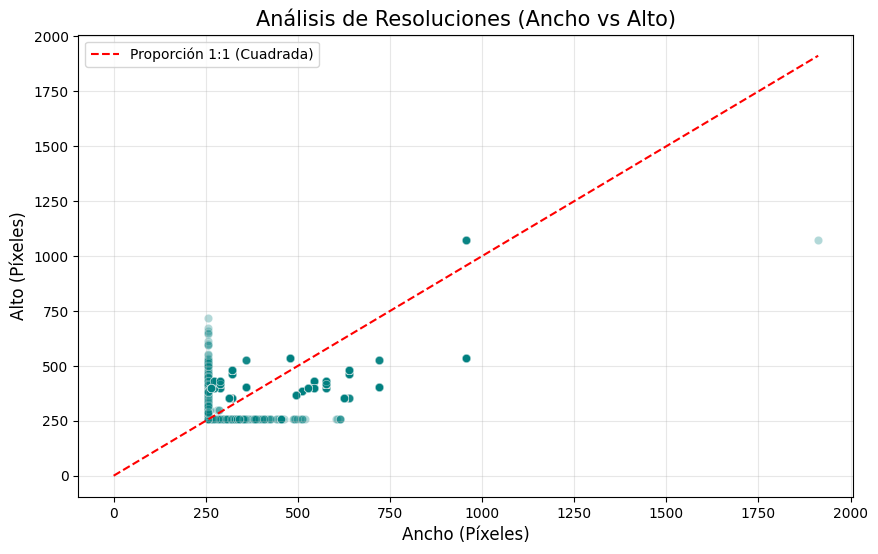

Ancho medio: 409 px | Alto medio: 416 px


In [4]:
def problema_resoluciones_imagenes():
    anchos = []
    altos = []

    # Tomamos una muestra de las imágenes de entrenamiento para analizar sus resoluciones
    for personaje in os.listdir(TRAIN_DIR):
        p = os.path.join(TRAIN_DIR, personaje)
        if os.path.isdir(p):
            imagenes = [f for f in os.listdir(p) if f.endswith('.jpg')][:500]
            for img_name in imagenes:
                img = os.path.join(p, img_name)
                with Image.open(img) as img:
                    w, h = img.size
                    anchos.append(w)
                    altos.append(h)

    # Visualización de la dispersión de tamaños
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=anchos, y=altos, alpha=0.3, color='teal')
    plt.title('Análisis de Resoluciones (Ancho vs Alto)', fontsize=15)
    plt.xlabel('Ancho (Píxeles)', fontsize=12)
    plt.ylabel('Alto (Píxeles)', fontsize=12)

    # Línea de proporción 1:1 (Cuadrada)
    max_val = max(max(anchos), max(altos))
    plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Proporción 1:1 (Cuadrada)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Ancho medio: {int(np.mean(anchos))} px | Alto medio: {int(np.mean(altos))} px")

problema_resoluciones_imagenes()

Las imágenes tienen tamaños variables y no son siempre perfectamente cuadradas, sin embargo, la mayoría de los modelos de CNN requieren entradas de tamaño fijo. 

Vamos a redimensionar las imágenes a **160×160 píxeles** `target_size=(160, 160)`. Este tamaño es el mínimo válido para MobileNetV2 (que acepta [96, 128, **160**, 192, 224]) y ofrece el mejor equilibrio entre calidad de representación y consumo de VRAM para las capacidades de la GPU disponible.

### Inspección cualitativa

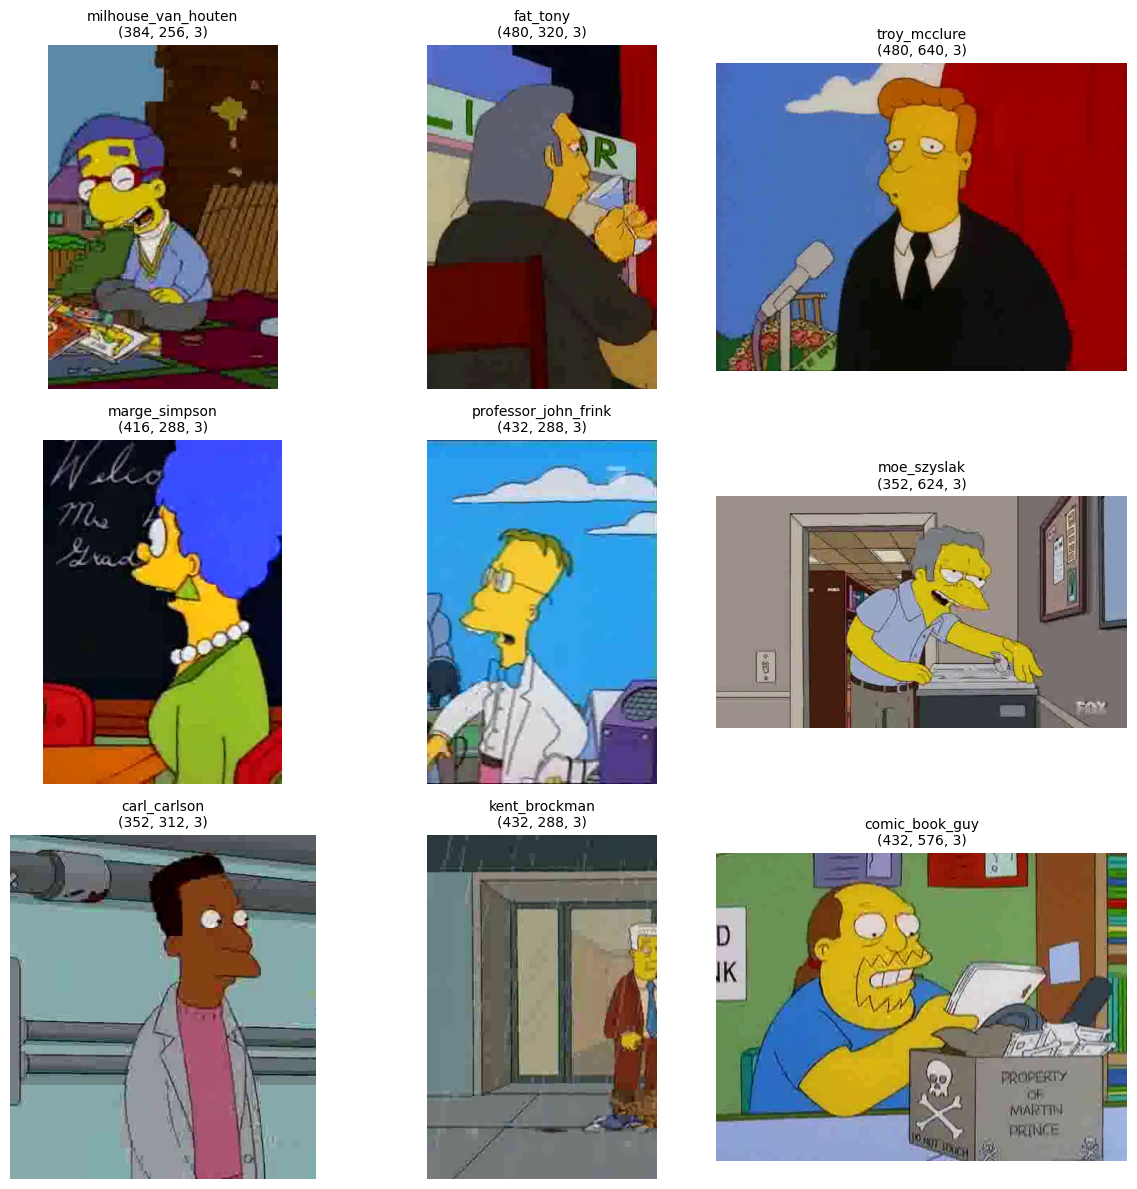

In [5]:
def mostrar_imagenes_aleatorias():

    clases_aleatorias = random.sample(os.listdir(TRAIN_DIR), 9)

    plt.figure(figsize=(12, 12))
    for i, personaje in enumerate(clases_aleatorias):
        p = os.path.join(TRAIN_DIR, personaje)
        # Cogemos la primera imagen de esa clase
        img_name = [f for f in os.listdir(p) if f.endswith('.jpg')][0]
        img_path = os.path.join(p, img_name)
        
        img = mpimg.imread(img_path)
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(f"{personaje}\n{img.shape}", fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

mostrar_imagenes_aleatorias()

## Preprocesamiento

### clases válidas

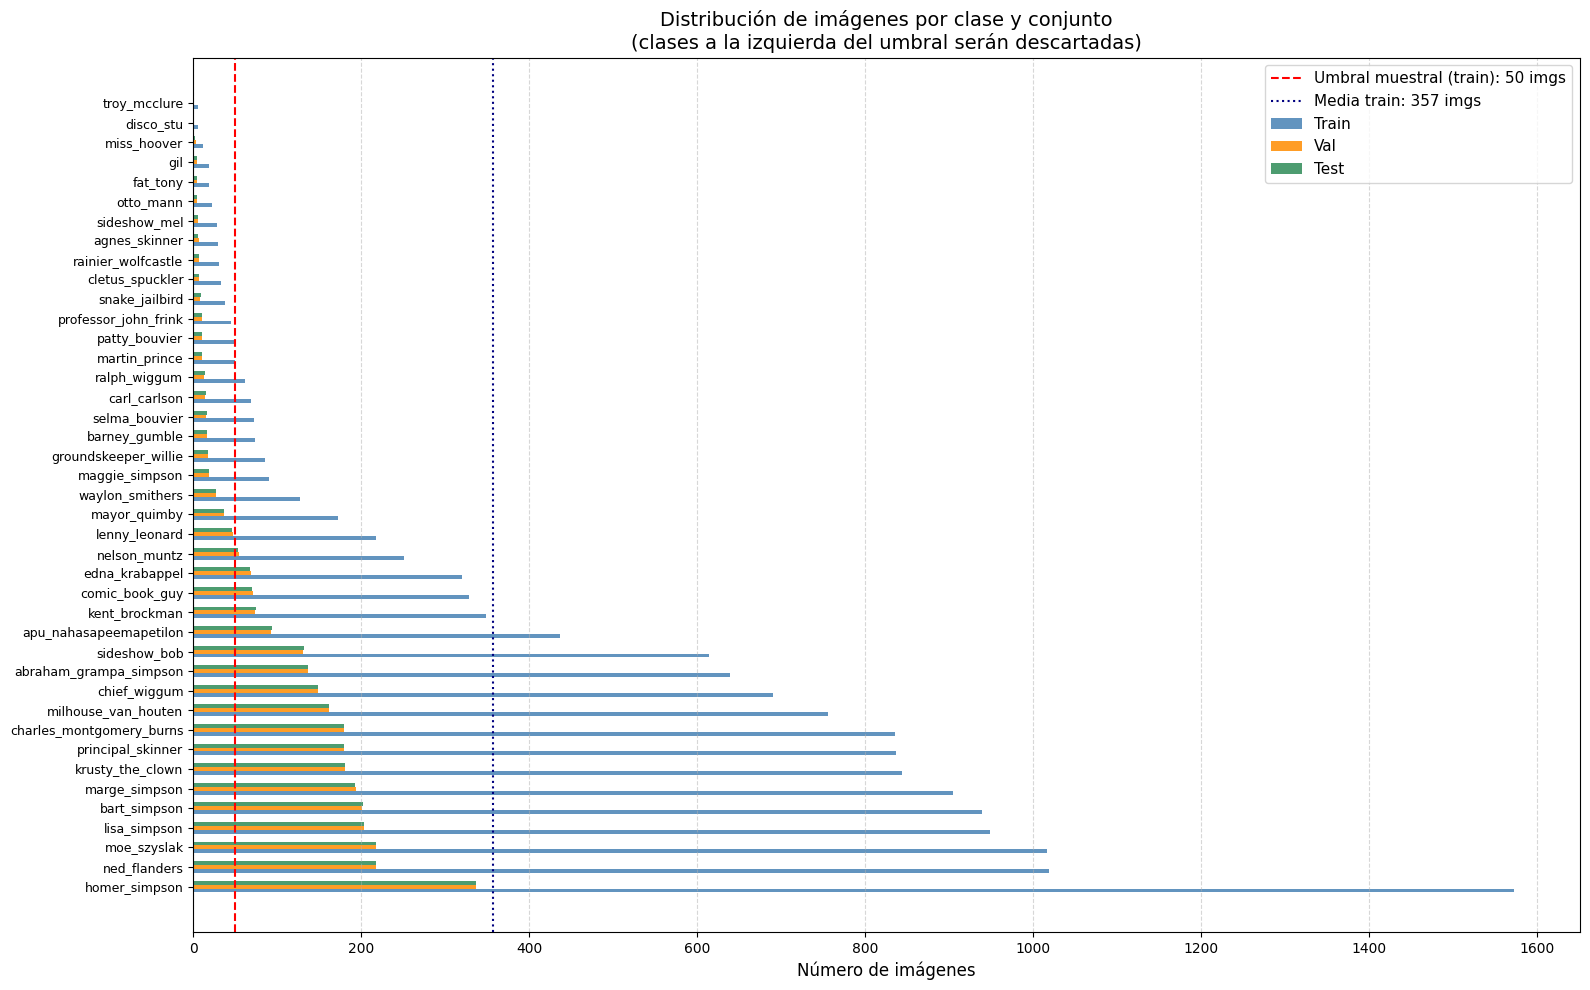


  Total de clases en disco : 41
  Clases viables (≥50)  : 29
  Clases descartadas (<50): 12

  Clases descartadas:
    ✗ professor_john_frink                train= 45  val= 10  test= 10
    ✗ snake_jailbird                      train= 38  val=  8  test=  9
    ✗ cletus_spuckler                     train= 33  val=  7  test=  7
    ✗ rainier_wolfcastle                  train= 31  val=  7  test=  7
    ✗ agnes_skinner                       train= 29  val=  7  test=  6
    ✗ sideshow_mel                        train= 28  val=  6  test=  6
    ✗ otto_mann                           train= 22  val=  5  test=  5
    ✗ fat_tony                            train= 19  val=  4  test=  4
    ✗ gil                                 train= 19  val=  4  test=  4
    ✗ miss_hoover                         train= 12  val=  3  test=  2
    ✗ disco_stu                           train=  6  val=  1  test=  1
    ✗ troy_mcclure                        train=  6  val=  1  test=  1


In [4]:
# ============================================================
# ANÁLISIS DE DISTRIBUCIÓN POST-SPLIT
# Verificamos que el split estratificado conserva las proporciones
# ============================================================

UMBRAL_MUESTRAL_TRAIN = 50  # para que tengan al menos muestra 10 en el conjunto de val y test

def identificar_clases_viables(train_dir: str, val_dir: str, test_dir: str,
                             umbral: int = UMBRAL_MUESTRAL_TRAIN, devolver=True):
    """
    Visualiza la distribución de imágenes por clase en los tres conjuntos
    y marca el umbral muestral para identificar clases no viables.
    """
    conteo = {'train': {}, 'val': {}, 'test': {}}

    for split, ruta in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
        for cls in sorted(os.listdir(ruta)):
            cls_path = os.path.join(ruta, cls)
            if os.path.isdir(cls_path):
                n = len([f for f in os.listdir(cls_path) if f.endswith('.jpg')])
                if n > 0:
                    conteo[split][cls] = n

    # Ordenar por cantidad en train de mayor a menor
    clases_ord = sorted(conteo['train'], key=conteo['train'].get, reverse=True)
    media_train = np.mean(list(conteo['train'].values()))

    fig, ax = plt.subplots(figsize=(16, 10))

    x      = np.arange(len(clases_ord))
    width  = 0.6
    colores = {'train': 'steelblue', 'val': 'darkorange', 'test': 'seagreen'}

    for i, (split, offset) in enumerate(zip(['train', 'val', 'test'],
                                             [-width/3, 0, width/3])):
        valores = [conteo[split].get(c, 0) for c in clases_ord]
        ax.barh(x + offset, valores, height=width/3,
                label=split.capitalize(), color=colores[split], alpha=0.85)

    ax.set_yticks(x)
    ax.set_yticklabels(clases_ord, fontsize=9)
    ax.axvline(umbral,     color='red',    linestyle='--', linewidth=1.5,
               label=f'Umbral muestral (train): {umbral} imgs')
    ax.axvline(media_train, color='navy', linestyle=':',  linewidth=1.5,
               label=f'Media train: {int(media_train)} imgs')
    ax.set_title('Distribución de imágenes por clase y conjunto\n'
                 '(clases a la izquierda del umbral serán descartadas)',
                 fontsize=14)
    ax.set_xlabel('Número de imágenes', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Resumen numérico
    clases_ok      = [c for c in clases_ord if conteo['train'].get(c, 0) >= umbral]
    clases_dropped = [c for c in clases_ord if conteo['train'].get(c, 0) <  umbral]

    print(f"\n  Total de clases en disco : {len(clases_ord)}")
    print(f"  Clases viables (≥{umbral})  : {len(clases_ok)}")
    print(f"  Clases descartadas (<{umbral}): {len(clases_dropped)}")
    print(f"\n  Clases descartadas:")
    for c in clases_dropped:
        print(f"    ✗ {c:<35} "
              f"train={conteo['train'].get(c,0):>3}  "
              f"val={conteo['val'].get(c,0):>3}  "
              f"test={conteo['test'].get(c,0):>3}")

    # return clases_ok, clases_dropped
    if devolver:
        return clases_ok, clases_dropped
    else:
        print()


clases_viables, clases_descartadas = identificar_clases_viables(
    TRAIN_DIR, VAL_DIR, TEST_DIR, umbral=UMBRAL_MUESTRAL_TRAIN
)

In [106]:
# ============================================================
# CONSTRUCCIÓN DE DATAFRAMES FILTRADOS
# Usamos DataFrames en lugar de flow_from_directory para tener
# control total sobre qué clases se incluyen en cada conjunto,
# sin necesidad de crear directorios temporales en disco.
# ============================================================

def build_dataframe(base_dir: str, clases_permitidas: list) -> pd.DataFrame:
    """
    Construye un DataFrame con columnas [filepath, label] para las
    clases que superan el umbral muestral.

    Args:
        base_dir:          directorio del split (train, val o test)
        clases_permitidas: lista de clases que superan el umbral

    Returns:
        DataFrame con una fila por imagen
    """
    filepaths, labels = [], []

    for cls in clases_permitidas:
        cls_path = os.path.join(base_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        for img in sorted(os.listdir(cls_path)):
            if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                filepaths.append(os.path.join(cls_path, img))
                labels.append(cls)

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    return df


# Construimos los tres DataFrames usando únicamente las clases viables
df_train = build_dataframe(TRAIN_DIR, clases_viables)
df_val   = build_dataframe(VAL_DIR,   clases_viables)
df_test  = build_dataframe(TEST_DIR,  clases_viables)

# Verificación
print(f"  df_train : {len(df_train):>5} imágenes — {df_train['label'].nunique()} clases")
print(f"  df_val   : {len(df_val):>5} imágenes — {df_val['label'].nunique()} clases")
print(f"  df_test  : {len(df_test):>5} imágenes — {df_test['label'].nunique()} clases")

# Comprobación de consistencia: las tres particiones deben tener exactamente las mismas clases
assert set(df_train['label'].unique()) == set(df_val['label'].unique()) == \
       set(df_test['label'].unique()), \
    "WARNING: Las clases no coinciden entre train/val/test. Revisa el split estratificado."

print("\n CHECK: Las tres particiones contienen exactamente las mismas clases.")

  df_train : 14362 imágenes — 29 clases
  df_val   :  3077 imágenes — 29 clases
  df_test  :  3078 imágenes — 29 clases

 CHECK: Las tres particiones contienen exactamente las mismas clases.


### generadores de datos

In [ ]:
# ============================================================
# GENERADORES DE DATOS
# ============================================================

def create_generators(df_train: pd.DataFrame,
                      df_val:   pd.DataFrame,
                      df_test:  pd.DataFrame,
                      preprocess_fn = None,
                      img_size      = IMG_SIZE,
                      batch_size    = GEN_BATCH_SIZE,
                      augment       = True):
    """
    Crea los tres generadores Keras a partir de DataFrames pre-filtrados.

    Args:
        df_train/val/test: DataFrames con columnas [filepath, label]
        preprocess_fn:     función de preprocesamiento del modelo base.
                           - mobilenet_preprocess → rango [-1, 1]
                           - resnet_preprocess    → centrado por canal ImageNet
                           - None                 → rescale 1./255, rango [0, 1]
        img_size:          tamaño de reescalado (H, W)
        batch_size:        tamaño del batch
        augment:           si True aplica Data Augmentation al generador de train

    Returns:
        train_gen, val_gen, test_gen
    """
    # ----------------------------------------------------------
    # 1. CONFIGURACIÓN DE DATA AUGMENTATION (solo train)
    # ----------------------------------------------------------
    aug_kwargs = dict(
        rotation_range    = 20,       # rotación leve (personajes no suelen estar invertidos)
        width_shift_range = 0.1,      # desplazamiento horizontal
        height_shift_range= 0.1,      # desplazamiento vertical
        shear_range       = 0.15,     # distorsión para compensar aspect ratios variables
        zoom_range        = 0.15,     # zoom para distintos encuadres
        horizontal_flip   = True,     # simetría horizontal válida en dibujos animados
        fill_mode         = 'nearest' # rellenar huecos tras transformaciones
    ) if augment else {}

    # ----------------------------------------------------------
    # 2. FUNCIÓN DE PREPROCESAMIENTO
    # Cada arquitectura preentrenada fue diseñada para un rango
    # de píxeles específico. Mezclarlos es un error silencioso
    # que degrada el rendimiento sin lanzar ningún aviso.
    # ----------------------------------------------------------
    if preprocess_fn is not None:
        train_dg = ImageDataGenerator(preprocessing_function=preprocess_fn, **aug_kwargs)
        val_dg   = ImageDataGenerator(preprocessing_function=preprocess_fn)
    else:
        train_dg = ImageDataGenerator(rescale=1./255, **aug_kwargs)
        val_dg   = ImageDataGenerator(rescale=1./255)

    # ----------------------------------------------------------
    # 3. GENERADORES DESDE DATAFRAME
    # flow_from_dataframe garantiza que los tres generadores ven
    # exactamente las mismas clases en el mismo orden, porque
    # comparten la misma lista de etiquetas del DataFrame.
    # ----------------------------------------------------------
    common = dict(
        x_col       = 'filepath',
        y_col       = 'label',
        target_size = img_size,
        batch_size  = batch_size,
        class_mode  = 'categorical',
    )

    train_gen = train_dg.flow_from_dataframe(df_train, shuffle=True,  **common)
    val_gen   = val_dg.flow_from_dataframe(df_val,   shuffle=False, **common)
    test_gen  = val_dg.flow_from_dataframe(df_test,  shuffle=False, **common)

    # ----------------------------------------------------------
    # 4. RESUMEN
    # ----------------------------------------------------------
    print(f"\n  Preprocesamiento  : "
          f"{'nativo ' + preprocess_fn.__module__.split('.')[-2] if preprocess_fn else 'rescale 1./255'}")
    print(f"  Data Augmentation : {'activado' if augment else 'desactivado'}")
    print(f"  Clases            : {len(train_gen.class_indices)}")
    print(f"  Imágenes train    : {train_gen.samples}")
    print(f"  Imágenes val      : {val_gen.samples}")
    print(f"  Imágenes test     : {test_gen.samples}")
    print(f"  Batch size        : {batch_size}")
    print(f"  Steps per epoch   : {train_gen.samples // batch_size}")

    return train_gen, val_gen, test_gen

## Modelos

In [7]:
NUM_CLASES = len(clases_viables)

### funciones auxiliares

In [8]:
def plot_history(history, title, colors=('blue', 'orange')):
    """
    Dibuja las curvas de accuracy y loss de un History de Keras.
    
    Args:
        > history: objeto devuelto por model.fit()
        > title: nombre del modelo (str)
        > colors: tupla (color_train, color_val)
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    metrics = [('accuracy', 'Accuracy'), ('loss', 'Loss')]
    for ax, (metric, label) in zip(axes, metrics):
        ax.plot(history.history[metric],
                label=f'Train {label}', color=colors[0], linewidth=2)
        ax.plot(history.history[f'val_{metric}'],
                label=f'Val {label}',   color=colors[1], linewidth=2)
        ax.set_title(f'{label} — {title}', fontsize=14)
        ax.set_xlabel('Época')
        ax.set_ylabel(label)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [ ]:
def validate_model(model, val_gen, model_name):
    """
    Evalúa el modelo en el conjunto de validación y muestra los resultados.

    Args:
        > model: modelo Keras entrenado
        > val_gen: generador de validación
        > model_name: nombre descriptivo del modelo (str)
    
    Returns:
        > val_loss: pérdida en el conjunto de validación
        > val_acc:  accuracy en el conjunto de validación
    """

    print(f"\n{'='*50}")
    print(f" EVALUACIÓN VALIDACIÓN — {model_name}")
    print(f"{'='*50}")
    
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    
    print(f"Val. Accuracy : {val_acc*100:.2f}%")
    print(f"Val. Loss: {val_loss:.4f}")
    
    return val_loss, val_acc

In [ ]:
class TimeHistory(Callback):
    """
    Callback personalizado para medir el tiempo total de entrenamiento y el tiempo medio por época.
    """
    def on_train_begin(self, logs={}):
        self.total_time_start = time.time()
        self.epoch_times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.epoch_times.append(time.time() - self.epoch_time_start)

    def on_train_end(self, logs={}):
        self.total_time = time.time() - self.total_time_start

        # Tiempo total
        minutos, segundos = divmod(self.total_time, 60)
        print(f"\nTiempo total de entrenamiento: {int(minutos)} min. {int(segundos)} seg.")

        # Tiempo medio por época
        epoch_time = np.mean(self.epoch_times)
        epoch_min, epoch_seg = divmod(epoch_time, 60)
        print(f"Tiempo medio por época: {int(epoch_min)} min. {int(epoch_seg)} seg.")

# Instanciar el callback
time_callback = TimeHistory()

### M1: Fully Connected

In [11]:
#---------------------------------------------------------------
# PREP DATOS
#---------------------------------------------------------------
# instanciamos los generadores necesarios para este modelo, en este caso, el rescale básico
train_gen_rescale, val_gen_rescale, test_gen_rescale = create_generators(df_train, df_val, df_test)

NAME_M1 = "Fully Connected"
RUTA_M1 = os.path.join(MODELS_DIR, 'm1_fully_connected.keras')

Found 14362 validated image filenames belonging to 29 classes.
Found 3077 validated image filenames belonging to 29 classes.
Found 3078 validated image filenames belonging to 29 classes.

  Preprocesamiento  : rescale 1./255
  Data Augmentation : activado
  Clases            : 29
  Imágenes train    : 14362
  Imágenes val      : 3077
  Imágenes test     : 3078
  Batch size        : 32
  Steps per epoch   : 448


In [12]:
#--------------------------------------------------------------
# ARQUITECTURA
#--------------------------------------------------------------
model_1 = Sequential([
    # Input y aplanado explícito
    keras.layers.Input(shape=(*IMG_SIZE, 3)),
    Flatten(),
    
    # Capas ocultas (perceptroón multicapa clásico)
    Dense(512, activation='relu'),
    Dropout(0.3),  # para evitar overfitting
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    
    # Capa de salida (Softmax para probabilidad multiclase)
    Dense(NUM_CLASES, activation='softmax')
])


model_1.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_1.summary()

W0000 00:00:1777319249.941063  119338 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1777319249.948303  119338 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777319250.561011  119338 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 76800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,490,077 (150.64 MB)

 Trainable params: 39,490,077 (150.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#--------------------------------------------------------------
# ENTRENAMIENTO
#--------------------------------------------------------------

callbacks_m1 = [
    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        min_lr = 1e-6,
        verbose = 1
    ),
    EarlyStopping(
        monitor = 'val_accuracy',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    ModelCheckpoint(
        filepath = RUTA_M1,
        monitor = 'val_accuracy',
        save_best_only = True,
        verbose = 1
    ),
    time_callback
]

history_1 = model_1.fit(
    train_gen_rescale,
    epochs = 20, 
    validation_data = val_gen_rescale,
    callbacks = callbacks_m1
)

Epoch 1/20


I0000 00:00:1777069537.674505  216268 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777069540.723988  216524 service.cc:153] XLA service 0x78137c032250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777069540.724046  216524 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1777069540.795877  216524 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777069541.181030  216524 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1777069541.281308  216524 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1788__.20
I0000 00:00:1777069544.111625  216603 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_Ma

  1/449 ━━━━━━━━━━━━━━━━━━━━ 1:35:58 13s/step - accuracy: 0.0000e+00 - loss: 3.5404

I0000 00:00:1777069550.350644  216524 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


310/449 ━━━━━━━━━━━━━━━━━━━━ 36s 264ms/step - accuracy: 0.0699 - loss: 8.6013

I0000 00:00:1777069632.622977  216527 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1788__.20
I0000 00:00:1777069633.477564  216981 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1777069634.557690  216988 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 24 bytes spill stores, 24 bytes spill loads

I0000 00:00:1777069635.090931  216990 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_16', 24 bytes spill stores, 24 bytes spill loads



449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.0773 - loss: 7.2748

I0000 00:00:1777069678.753815  217310 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 4 bytes spill stores, 4 bytes spill loads




Epoch 1: val_accuracy improved from None to 0.10952, saving model to ./modelos/m1_fully_connected.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 159s 327ms/step - accuracy: 0.0948 - loss: 4.1102 - val_accuracy: 0.1095 - val_loss: 3.0264 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.1083 - loss: 3.0336
Epoch 2: val_accuracy did not improve from 0.10952
449/449 ━━━━━━━━━━━━━━━━━━━━ 124s 275ms/step - accuracy: 0.1093 - loss: 3.0292 - val_accuracy: 0.1095 - val_loss: 3.0218 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.1102 - loss: 3.0318
Epoch 3: val_accuracy did not improve from 0.10952
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 227ms/step - accuracy: 0.1095 - loss: 3.0259 - val_accuracy: 0.1095 - val_loss: 3.0229 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.1098 - loss: 3.0296
Epoch 4: val_accuracy did not improve from 0.10952
449/449 ━━━━━━━━━━━━━━━━━━━━ 121s 270ms/ste


 EVALUACIÓN VALIDACIÓN — Fully Connected
Val. Accuracy : 10.95%
Val. Loss: 3.0264


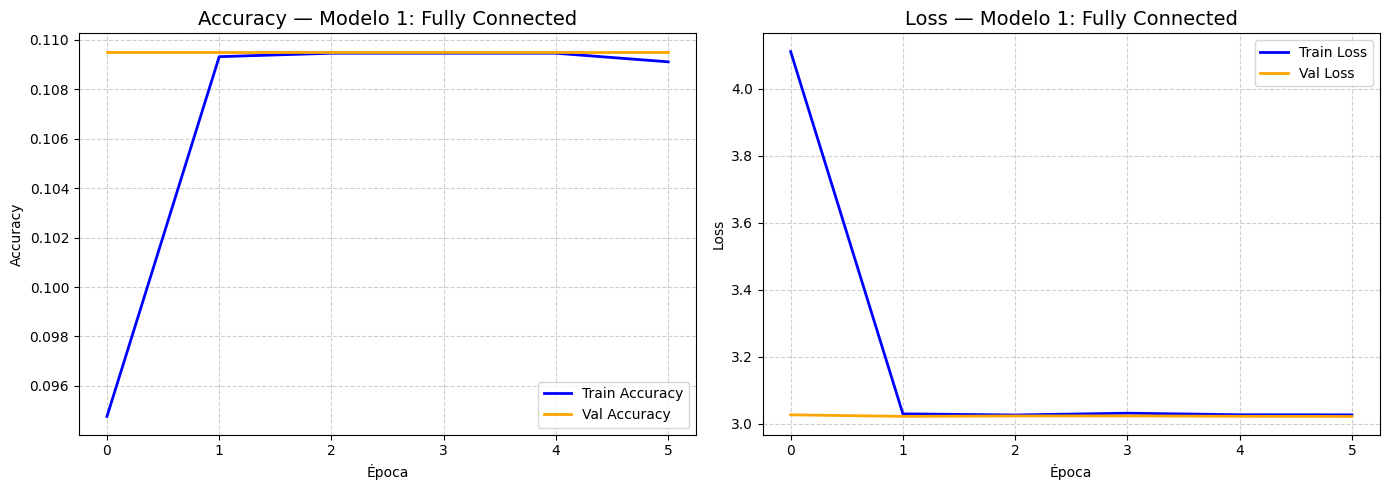

In [ ]:
#---------------------------------------------------------------
# EVALUACIÓN
#---------------------------------------------------------------
val_loss_1, val_acc_1 = validate_model(model_1, val_gen_rescale, NAME_M1)
plot_history(history_1, title=NAME_M1)

### M2: CNN

In [13]:
NAME_M2 = "CNN"
RUTA_M2 = os.path.join(MODELS_DIR, 'm2_cnn.keras')

In [14]:
#---------------------------------------------------------------
# ARQUITECTURA
#---------------------------------------------------------------
model_2 = Sequential([
    Input(shape=(*IMG_SIZE, 3)),

    # BLOQUE 1: Detectar patrones muy simples (bordes, colores)
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # BLOQUE 2: Detectar texturas y formas básicas
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),  # regularización para evitar overfitting

    # BLOQUE 3: Detectar partes complejas (ojos, narices, pelo)
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # CLASIFICADOR 
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4), 
    Dense(NUM_CLASES, activation='softmax')
])

model_2.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,652,125 (25.38 MB)

 Trainable params: 6,651,421 (25.37 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
#---------------------------------------------------------------
# ENTRENAMIENTO
#---------------------------------------------------------------

callbacks_m2 = [
    ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.5,
        patience = 3,
        min_lr = 1e-6,
        verbose = 1
    ),
    EarlyStopping(
        monitor = 'val_accuracy',
        patience = 5,
        restore_best_weights = True,
        verbose = 1
    ),
    ModelCheckpoint(
        filepath = RUTA_M2,
        monitor = 'val_accuracy',
        save_best_only = True,
        verbose = 1
    ),
    time_callback
]

history_2 = model_2.fit(
    train_gen_rescale,
    epochs = 20, 
    validation_data = val_gen_rescale,
    callbacks = callbacks_m2
)

Epoch 1/20


I0000 00:00:1777070283.631413  216527 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19908__.68


229/449 ━━━━━━━━━━━━━━━━━━━━ 57s 263ms/step - accuracy: 0.1807 - loss: 3.3220

I0000 00:00:1777070358.679842  216526 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19908__.68
I0000 00:00:1777070360.524942  219747 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_14', 4 bytes spill stores, 4 bytes spill loads



449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.2324 - loss: 3.0487
Epoch 1: val_accuracy improved from None to 0.20962, saving model to ./modelos/m2_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 159s 314ms/step - accuracy: 0.3189 - loss: 2.6059 - val_accuracy: 0.2096 - val_loss: 7.7721 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4332 - loss: 2.0515
Epoch 2: val_accuracy improved from 0.20962 to 0.54599, saving model to ./modelos/m2_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 124s 276ms/step - accuracy: 0.4575 - loss: 1.9606 - val_accuracy: 0.5460 - val_loss: 1.7832 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.5226 - loss: 1.6784
Epoch 3: val_accuracy improved from 0.54599 to 0.60058, saving model to ./modelos/m2_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 103s 229ms/step - accuracy: 0.5393 - loss: 1.6330 - val_accuracy: 0.6006 - val_loss: 1.8708 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━


 EVALUACIÓN VALIDACIÓN — CNN
Val. Accuracy : 89.60%
Val. Loss: 0.4120


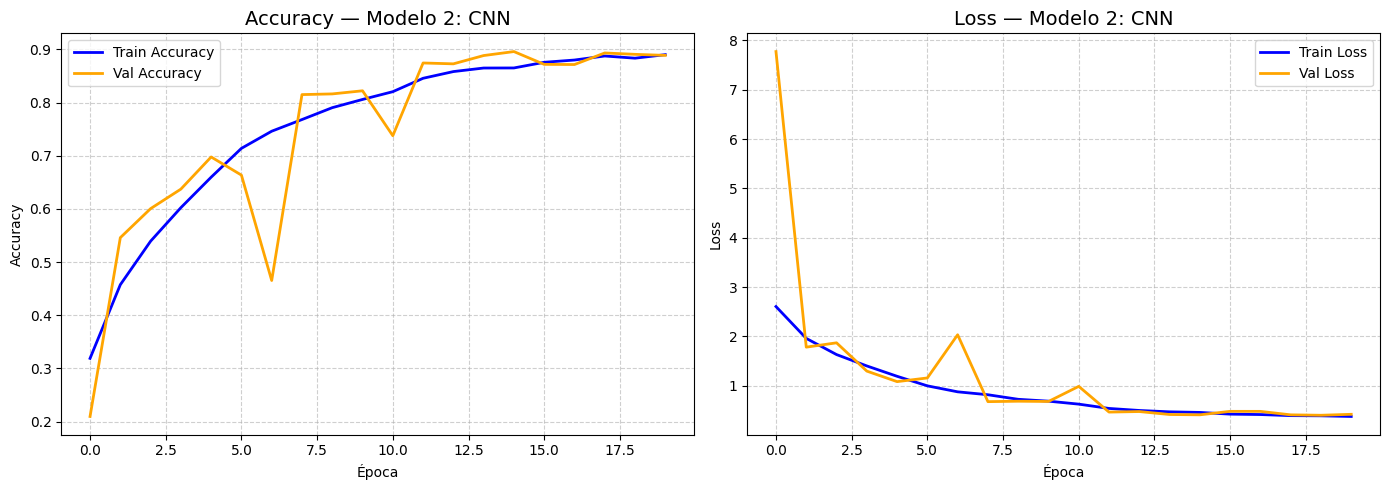

In [ ]:
#---------------------------------------------------------------
# EVALUACIÓN
#---------------------------------------------------------------
val_loss_2, val_acc_2 = validate_model(model_2, val_gen_rescale, NAME_M2)
plot_history(history_2, title=NAME_M2)

### M3: ResNet50

In [15]:
#---------------------------------------------------------------
# PREP DATOS
#---------------------------------------------------------------
# Instanciamos los generadores necesarios para este modelo, con el preprocesamiento específico de ResNet50
train_gen_resnet_m3, val_gen_resnet_m3, test_gen_resnet_m3 = create_generators(
    df_train, df_val, df_test,
    preprocess_fn = resnet_preprocess
)

NAME_M3 = "Transfer Learning (ResNet50)"
RUTA_M3 = os.path.join(MODELS_DIR, 'm3_resnet.keras')

Found 14362 validated image filenames belonging to 29 classes.
Found 3077 validated image filenames belonging to 29 classes.
Found 3078 validated image filenames belonging to 29 classes.

  Preprocesamiento  : nativo applications
  Data Augmentation : activado
  Clases            : 29
  Imágenes train    : 14362
  Imágenes val      : 3077
  Imágenes test     : 3078
  Batch size        : 32
  Steps per epoch   : 448


In [16]:
#---------------------------------------------------------------
# ARQUITECTURA
#---------------------------------------------------------------
modelo_base_resnet = ResNet50(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

modelo_base_resnet.trainable = False  # Congela los pesos del modelo base
# usamos ResNet

# Construimos la cabeza clasificadora
model_3 = Sequential([
    modelo_base_resnet,  # Modelo base preentrenado
    GlobalAveragePooling2D(),  # Reduce la dimensionalidad sin perder información espacial importante

    # Capas densas finales para clasificación
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), # Fuerte regularización porque ResNet50 tiende a sobreajustar
    Dense(NUM_CLASES, activation='softmax')
])

model_3.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,653,725 (94.05 MB)

 Trainable params: 1,064,989 (4.06 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [ ]:
#---------------------------------------------------------------
# ENTRENAMIENTO
#---------------------------------------------------------------

callbacks_m3 = [
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = RUTA_M3,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    time_callback
]


history_3 = model_3.fit(
    train_gen_resnet_m3,
    epochs = 30, 
    validation_data = val_gen_resnet_m3,
    callbacks = callbacks_m3
)

Epoch 1/30


I0000 00:00:1777105564.966097    2575 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1777105571.978273    3334 service.cc:153] XLA service 0x7bcf6c0369d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777105571.978343    3334 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1777105572.334427    3334 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777105575.124572    3334 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1777105575.352283    3334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11460__.192


  1/449 ━━━━━━━━━━━━━━━━━━━━ 3:03:55 25s/step - accuracy: 0.0000e+00 - loss: 4.9902

I0000 00:00:1777105589.375727    3334 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


139/449 ━━━━━━━━━━━━━━━━━━━━ 1:31 295ms/step - accuracy: 0.2532 - loss: 3.1968

I0000 00:00:1777105633.335581    3332 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_11460__.192
I0000 00:00:1777105637.803868    3942 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1777105638.204350    3937 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 24 bytes spill stores, 24 bytes spill loads



449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.3817 - loss: 2.4944
Epoch 1: val_accuracy improved from None to 0.65096, saving model to ./modelos/m3_resnet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 210s 415ms/step - accuracy: 0.4872 - loss: 1.9450 - val_accuracy: 0.6510 - val_loss: 1.2853 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.6196 - loss: 1.3447
Epoch 2: val_accuracy improved from 0.65096 to 0.70231, saving model to ./modelos/m3_resnet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 136s 302ms/step - accuracy: 0.6324 - loss: 1.3039 - val_accuracy: 0.7023 - val_loss: 1.0874 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6633 - loss: 1.1691
Epoch 3: val_accuracy improved from 0.70231 to 0.72246, saving model to ./modelos/m3_resnet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 115s 256ms/step - accuracy: 0.6690 - loss: 1.1493 - val_accuracy: 0.7225 - val_loss: 1.0216 - learning_rate: 0.0010
Epoch 4/30
449/449 ━━


 EVALUACIÓN VALIDACIÓN — Transfer Learning (ResNet50)
Val. Accuracy : 4.35%
Val. Loss: 4.2891


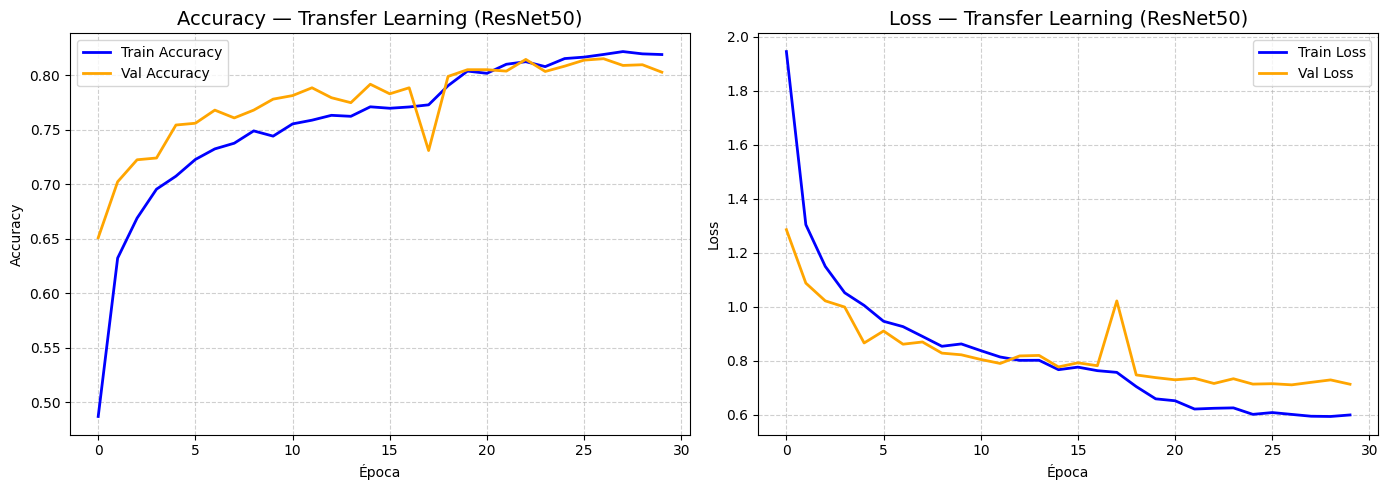

In [ ]:
#---------------------------------------------------------------
# EVALUACIÓN
#---------------------------------------------------------------
val_loss_3, val_acc_3 = validate_model(model_3, val_gen_resnet_m3, NAME_M3)
plot_history(history_3, title=NAME_M3)

### M3.2: ResNet50 arquitectura modificada

In [17]:
train_gen_resnet_m3b, val_gen_resnet_m3b, test_gen_resnet_m3b = create_generators(
    df_train, df_val, df_test, preprocess_fn=resnet_preprocess
)

NAME_M3_B = "Transfer Learning (ResNet50) - ajustado"
RUTA_M3_B = os.path.join(MODELS_DIR, 'm3_resnet_ajust.keras')

Found 14362 validated image filenames belonging to 29 classes.
Found 3077 validated image filenames belonging to 29 classes.
Found 3078 validated image filenames belonging to 29 classes.

  Preprocesamiento  : nativo applications
  Data Augmentation : activado
  Clases            : 29
  Imágenes train    : 14362
  Imágenes val      : 3077
  Imágenes test     : 3078
  Batch size        : 32
  Steps per epoch   : 448


In [18]:
#---------------------------------------------------------------
# Fine tuninng de la ARQUITECTURA
#---------------------------------------------------------------
# Nueva instancia limpia — sin ningún entrenamiento previo
modelo_base_resnet_bis = ResNet50(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'   # pesos ImageNet puros, sin tocar
)

# ESTRATEGIA DE DESCONGELADO
# ResNet50 se organiza en 5 bloques convolucionales:
#   conv1 + conv2_x:  capas  0-37  → bordes, texturas simples    CONGELAR
#   conv3_x        :  capas 37-75  → formas geométricas básicas  CONGELAR
#   conv4_x        :  capas 75-143 → estructuras complejas       DESCONGELAR
#   conv5_x        :  capas 143-175→ representaciones de alto nivel DESCONGELAR
#
# Descongelamos solo conv4_x y conv5_x (desde capa 75).
# Más agresivo que el estándar (80) porque nuestro dominio
# (dibujos animados) es suficientemente distinto de ImageNet
# como para necesitar reajustar más capas de alto nivel.

# Descongelar conv4_x + conv5_x desde el inicio (sin Fase 1)
FINE_TUNE_AT_RESNET = 75

modelo_base_resnet_bis.trainable = True
for layer in modelo_base_resnet_bis.layers[:FINE_TUNE_AT_RESNET]:
    layer.trainable = False

# Congelar BN del modelo base: sus estadísticas fueron calibradas con ImageNet, y si se actualizan con este dataset podría casuar inconsistencias.
for layer in modelo_base_resnet_bis.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_3_bis = Sequential([
    modelo_base_resnet_bis,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASES, activation='softmax')
])

# Estadísticas de parámetros
n_trainable      = int(sum(tf.size(v).numpy() for v in model_3_bis.trainable_variables))
n_no_trainable   = int(sum(tf.size(v).numpy() for v in model_3_bis.non_trainable_variables))
n_total          = n_trainable + n_no_trainable

print(f"\n  Capas congeladas      : {FINE_TUNE_AT_RESNET} "
      f"(conv1 + conv2_x + conv3_x)")
print(f"  Capas entrenables     : {len(modelo_base_resnet_bis.layers) - FINE_TUNE_AT_RESNET} "
      f"(conv4_x + conv5_x + cabeza)")
print(f"  Parámetros entrenables: {n_trainable:,} "
      f"({100.0 * n_trainable / n_total:.1f}% del total)")
print(f"  Parámetros congelados : {n_no_trainable:,} "
      f"({100.0 * n_no_trainable / n_total:.1f}% del total)")




#---------------------------------------------------------------
# COMPILACIÓN
#---------------------------------------------------------------
model_3_bis.compile(
    optimizer = Adam(learning_rate=3e-4),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)




  Capas congeladas      : 75 (conv1 + conv2_x + conv3_x)
  Capas entrenables     : 100 (conv4_x + conv5_x + cabeza)
  Parámetros entrenables: 23,171,613 (94.0% del total)
  Parámetros congelados : 1,480,066 (6.0% del total)


In [ ]:
#---------------------------------------------------------------
# ENTRENAMIENTO
#---------------------------------------------------------------

callbacks_m3_bis = [
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-7,
        verbose  = 1
    ),
    EarlyStopping(
        monitor = 'val_accuracy',
        patience = 6,
        restore_best_weights = True,
        verbose = 1
    ),
    ModelCheckpoint(
        filepath       = RUTA_M3_B,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    time_callback
]


history_3_bis = model_3_bis.fit(
    train_gen_resnet_m3b,
    epochs = 30,
    validation_data = val_gen_resnet_m3b,
    callbacks = callbacks_m3_bis
)

Epoch 1/30


I0000 00:00:1777109820.966102    3333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138196__.186


 25/449 ━━━━━━━━━━━━━━━━━━━━ 1:36 228ms/step - accuracy: 0.0894 - loss: 3.4722

I0000 00:00:1777109844.979756    3334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_138196__.186


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.1799 - loss: 2.8950
Epoch 1: val_accuracy improved from None to 0.75333, saving model to ./modelos/m3_resnet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 173s 313ms/step - accuracy: 0.3550 - loss: 2.2994 - val_accuracy: 0.7533 - val_loss: 0.9236 - learning_rate: 3.0000e-04
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.7861 - loss: 0.8119
Epoch 2: val_accuracy improved from 0.75333 to 0.84953, saving model to ./modelos/m3_resnet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 133s 296ms/step - accuracy: 0.8123 - loss: 0.7111 - val_accuracy: 0.8495 - val_loss: 0.5483 - learning_rate: 3.0000e-04
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.8785 - loss: 0.4628
Epoch 3: val_accuracy improved from 0.84953 to 0.90803, saving model to ./modelos/m3_resnet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 147s 328ms/step - accuracy: 0.8796 - loss: 0.4510 - val_accuracy: 0.9080 - val_loss: 0.3452 - learning_rate: 3.


 EVALUACIÓN VALIDACIÓN — Transfer Learning (ResNet50) - ajustado
Val. Accuracy : 97.69%
Val. Loss: 0.1371


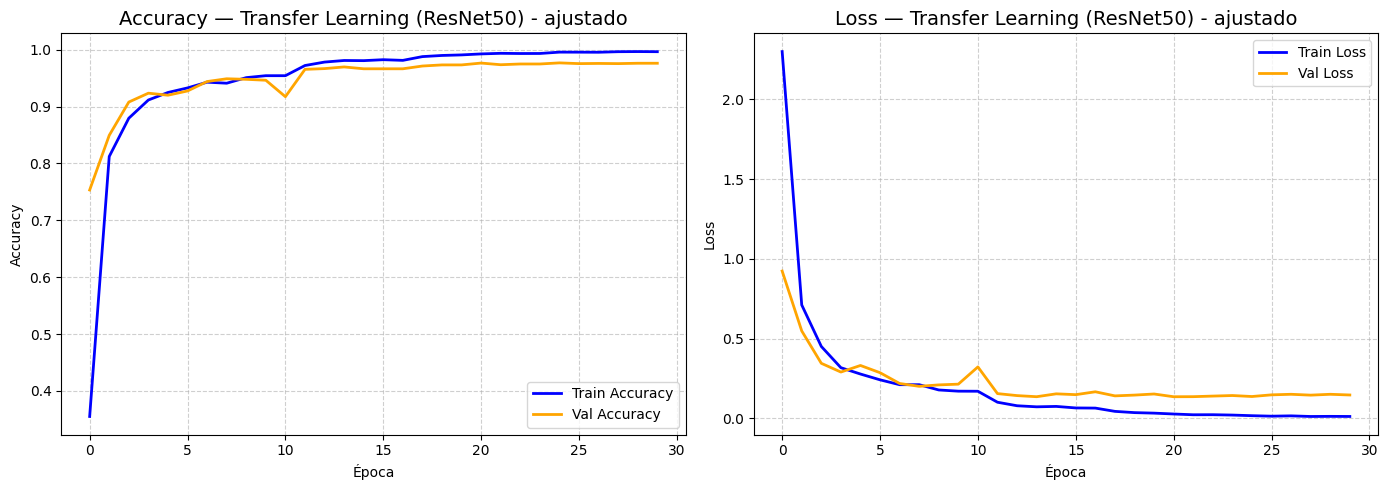

In [ ]:
validate_model(model_3_bis, val_gen_resnet_m3b, NAME_M3_B)
plot_history(history_3_bis, NAME_M3_B)

### M4: MobileNetV2

In [19]:
#---------------------------------------------------------------
# PREP DATOS
#---------------------------------------------------------------
# ResNet50 (su propio preprocess_input)
train_gen_mobilenet_m4, val_gen_mobilenet_m4, test_gen_mobilenet_m4 = create_generators(
    df_train, df_val, df_test,
    preprocess_fn = mobilenet_preprocess
)

NAME_M4 = "Transfer Learning (MobileNetV2)"
RUTA_M4 = os.path.join(MODELS_DIR, 'm4_mobilenet.keras')

Found 14362 validated image filenames belonging to 29 classes.
Found 3077 validated image filenames belonging to 29 classes.
Found 3078 validated image filenames belonging to 29 classes.

  Preprocesamiento  : nativo applications
  Data Augmentation : activado
  Clases            : 29
  Imágenes train    : 14362
  Imágenes val      : 3077
  Imágenes test     : 3078
  Batch size        : 32
  Steps per epoch   : 448


In [20]:
#---------------------------------------------------------------
# ARQUITECTURA
#---------------------------------------------------------------
modelo_base_mobilenet = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

modelo_base_mobilenet.trainable = False  # Congela los pesos del modelo base

# Construimos la cabeza clasificadora
model_4 = Sequential([
    modelo_base_mobilenet,
    GlobalAveragePooling2D(),

    # Capa clasificadora
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), # regularización fuerte
    Dense(NUM_CLASES, activation='softmax')
])

model_4.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,397 (9.90 MB)

 Trainable params: 335,901 (1.28 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [ ]:
#---------------------------------------------------------------
# ENTRENAMIENTO
#---------------------------------------------------------------

callbacks_m4 = [
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 5,
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = RUTA_M4,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    time_callback
]

history_4 = model_4.fit(
    train_gen_mobilenet_m4,
    epochs = 20, 
    validation_data = val_gen_mobilenet_m4,
    callbacks = callbacks_m4
)

Epoch 1/20


I0000 00:00:1777113480.109303    3334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237794__.129
E0000 00:00:1777113483.488105    3334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777113487.372317    3334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


276/449 ━━━━━━━━━━━━━━━━━━━━ 34s 200ms/step - accuracy: 0.2846 - loss: 2.9087

I0000 00:00:1777113569.368251    3331 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_237794__.129
E0000 00:00:1777113572.407290    3331 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777113586.945583    3331 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.3392 - loss: 2.6361

E0000 00:00:1777113653.862750    3334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777113657.341759    3334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.56451, saving model to ./modelos/m4_mobilenet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 205s 370ms/step - accuracy: 0.4476 - loss: 2.1014 - val_accuracy: 0.5645 - val_loss: 1.5384 - learning_rate: 0.0010
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.5722 - loss: 1.5067
Epoch 2: val_accuracy improved from 0.56451 to 0.63178, saving model to ./modelos/m4_mobilenet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 117s 261ms/step - accuracy: 0.5796 - loss: 1.4945 - val_accuracy: 0.6318 - val_loss: 1.3197 - learning_rate: 0.0010
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.6148 - loss: 1.3381
Epoch 3: val_accuracy improved from 0.63178 to 0.64998, saving model to ./modelos/m4_mobilenet.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 104s 231ms/step - accuracy: 0.6126 - loss: 1.3357 - val_accuracy: 0.6500 - val_loss: 1.2380 - learning_rate: 0.0010
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.6361 - loss: 1.2735



 EVALUACIÓN VALIDACIÓN — Transfer Learning (MobileNetV2)
Val. Accuracy : 68.80%
Val. Loss: 1.1451


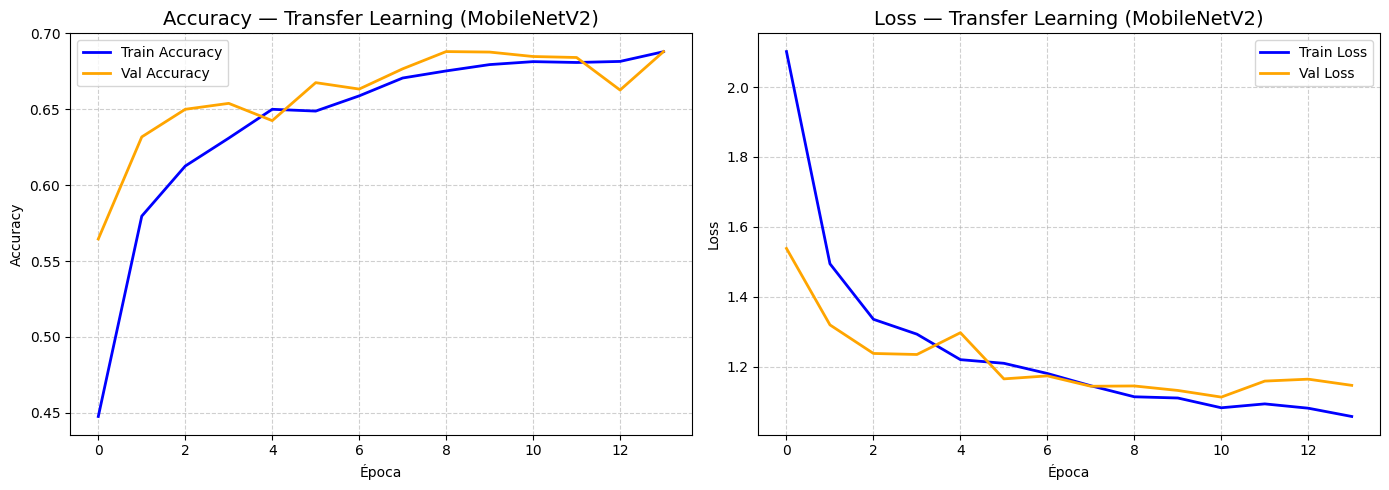

In [ ]:
#---------------------------------------------------------------
# EVALUACIÓN
#---------------------------------------------------------------
val_loss_4, val_acc_4 = validate_model(model_4, val_gen_mobilenet_m4, NAME_M4)
plot_history(history_4, title=NAME_M4)

### M4.2: MobileNetV2 arquitectura modificada

In [21]:
train_gen_mobilenet_m4b, val_gen_mobilenet_m4b, test_gen_mobilenet_m4b = create_generators(
    df_train, df_val, df_test, preprocess_fn=mobilenet_preprocess
)

NAME_M4_B = "Transfer Learning (MobileNetV2) - ajustado"
RUTA_M4_B = os.path.join(MODELS_DIR, 'm4_mobilenet_ajust.keras')

Found 14362 validated image filenames belonging to 29 classes.
Found 3077 validated image filenames belonging to 29 classes.
Found 3078 validated image filenames belonging to 29 classes.

  Preprocesamiento  : nativo applications
  Data Augmentation : activado
  Clases            : 29
  Imágenes train    : 14362
  Imágenes val      : 3077
  Imágenes test     : 3078
  Batch size        : 32
  Steps per epoch   : 448


In [22]:
#---------------------------------------------------------------
# MODEL_4_BIS — Fine-tuning directo SIN Fase 1 previa (MobileNetV2)
# Objetivo: comparar empíricamente si entrenar la cabeza primero
# (Fase 1) mejora el resultado final respecto a fine-tuning directo.
#
# Partimos de MobileNetV2 con pesos ImageNet completamente frescos
# (nueva instancia, sin ningún entrenamiento previo en Simpsons)
# y aplicamos fine-tuning directamente desde el inicio.
#---------------------------------------------------------------

# Nueva instancia limpia — independiente del modelo_base_mobilenet
# que ya fue modificado en la Fase 1 de model_4
modelo_base_mobilenet_bis = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'   # pesos ImageNet puros, sin tocar
)

# Mismo punto de descongelado que en la Fase 2 de model_4
# para que la comparativa sea justa: mismas capas entrenables,
# única diferencia es si la cabeza fue pre-entrenada o no.
FINE_TUNE_AT_MOBILE = 100

modelo_base_mobilenet_bis.trainable = True
for layer in modelo_base_mobilenet_bis.layers[:FINE_TUNE_AT_MOBILE]:
    layer.trainable = False

# Nota: a diferencia de ResNet50, MobileNetV2 usa BatchNormalization
# de forma más integrada en sus bloques invertidos. Sin embargo,
# congelarlas igualmente es la práctica más segura para preservar
# las estadísticas de ImageNet en las capas que no entrenamos.
for layer in modelo_base_mobilenet_bis.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_4_bis = Sequential([
    modelo_base_mobilenet_bis,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),  # esta BN sí es entrenable: es nuestra cabeza, no del modelo base
    Dropout(0.5),
    Dense(NUM_CLASES, activation='softmax')
])


#---------------------------------------------------------------
# COMPILACIÓN
#---------------------------------------------------------------
# LR intermedio entre Fase 1 (1e-3) y Fase 2 (1e-4):
# - más alto que 1e-4 porque la cabeza parte de cero y necesita aprender
# - más bajo que 1e-3 porque las capas descongeladas son sensibles
#   a pasos grandes que pueden destruir los pesos de ImageNet
model_4_bis.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


n_trainable = int(sum(tf.size(v).numpy() for v in model_4_bis.trainable_variables))
n_total     = n_trainable + \
              int(sum(tf.size(v).numpy() for v in model_4_bis.non_trainable_variables))

print(f"  Modelo base            : MobileNetV2 (pesos ImageNet frescos)")
print(f"  Punto de descongelado  : capa {FINE_TUNE_AT_MOBILE}")
print(f"  Parámetros entrenables : {n_trainable:,} ({100*n_trainable/n_total:.1f}%)")

  Modelo base            : MobileNetV2 (pesos ImageNet frescos)
  Punto de descongelado  : capa 100
  Parámetros entrenables : 2,175,517 (83.9%)


In [ ]:
#---------------------------------------------------------------
# ENTRENAMIENTO
#---------------------------------------------------------------

callbacks_m4_bis = [
    ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 3,    # más tolerante que en fine-tuning post-Fase 1
        min_lr   = 1e-7, # la cabeza necesita más épocas para estabilizarse
        verbose  = 1
    ),
    EarlyStopping(
        monitor              = 'val_accuracy',
        patience             = 7,    # más margen: convergencia más lenta sin Fase 1
        restore_best_weights = True,
        verbose              = 1
    ),
    ModelCheckpoint(
        filepath       = RUTA_M4_B,
        monitor        = 'val_accuracy',
        save_best_only = True,
        verbose        = 1
    ),
    time_callback
]

history_4_bis = model_4_bis.fit(
    train_gen_mobilenet_m4b,
    epochs          = 30,
    validation_data = val_gen_mobilenet_m4b,
    callbacks       = callbacks_m4_bis
)

Epoch 1/30


I0000 00:00:1777115146.482171    3334 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288840__.129
E0000 00:00:1777115148.066264    3334 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


258/449 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.1145 - loss: 3.7357

I0000 00:00:1777115222.106430    3333 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_288840__.129
E0000 00:00:1777115225.306067    3333 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.2028 - loss: 3.2925
Epoch 1: val_accuracy improved from None to 0.61911, saving model to ./modelos/m4_mobilenet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 172s 321ms/step - accuracy: 0.3921 - loss: 2.4102 - val_accuracy: 0.6191 - val_loss: 1.4198 - learning_rate: 1.0000e-04
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.7197 - loss: 1.1035
Epoch 2: val_accuracy improved from 0.61911 to 0.63471, saving model to ./modelos/m4_mobilenet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 118s 262ms/step - accuracy: 0.7428 - loss: 1.0138 - val_accuracy: 0.6347 - val_loss: 1.5058 - learning_rate: 1.0000e-04
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.8121 - loss: 0.7359
Epoch 3: val_accuracy improved from 0.63471 to 0.82710, saving model to ./modelos/m4_mobilenet_ajust.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 251ms/step - accuracy: 0.8229 - loss: 0.6872 - val_accuracy: 0.8271 - val_loss: 0.6835 - learning


 EVALUACIÓN VALIDACIÓN — Transfer Learning (MobileNetV2) - ajustado


E0000 00:00:1777118381.513578    3331 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777118392.642976    3331 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Val. Accuracy : 95.81%
Val. Loss: 0.1894


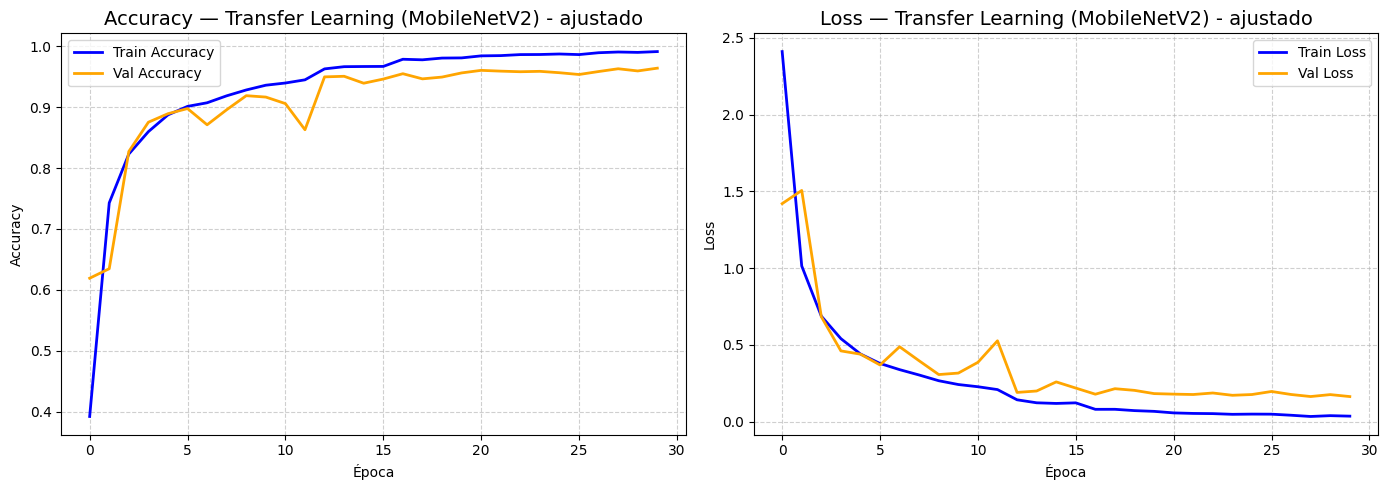

In [ ]:
validate_model(model_4_bis, test_gen_mobilenet_m4, NAME_M4_B)
plot_history(history_4_bis, title=NAME_M4_B)

## Comparativa de modelos

In [31]:
val_results = {}

def validar_modelo_desde_path(model_path: str, val_gen, model_name: str):
    """
    Carga un modelo guardado en disco y lo evalúa en el conjunto de validación.

    Args:
        model_path: ruta al archivo .keras del modelo guardado
        val_gen:   generador de validación correspondiente al modelo

    Returns:
        val_loss, val_acc
    """
    print(f"\n{'='*50}")
    print(f" EVALUACIÓN VALIDACIÓN — {os.path.basename(model_path)}")
    print(f"{'='*50}")
    
    # Cargar el modelo desde disco
    model = tf.keras.models.load_model(model_path)
    
    # Evaluar en el conjunto de validación
    val_loss, val_acc = model.evaluate(val_gen, verbose=0)
    
    print(f"Val. Accuracy : {val_acc*100:.2f}%")
    print(f"Val. Loss: {val_loss:.4f}")

    # Guardamos los resultados para la comparativa final
    val_results[model_name] = {
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'params': model.count_params()
    }
    
    return val_loss, val_acc

# validar todos los mmodelos desde sus rutas
m1_val_loss, m1_val_acc = validar_modelo_desde_path(RUTA_M1, val_gen_rescale, NAME_M1)
m2_val_loss, m2_val_acc = validar_modelo_desde_path(RUTA_M2, val_gen_rescale, NAME_M2)
m3_val_loss, m3_val_acc = validar_modelo_desde_path(RUTA_M3, val_gen_resnet_m3, NAME_M3)
m3b_val_loss, m3b_val_acc = validar_modelo_desde_path(RUTA_M3_B, val_gen_resnet_m3b, NAME_M3_B)
m4_val_loss, m4_val_acc = validar_modelo_desde_path(RUTA_M4, val_gen_mobilenet_m4, NAME_M4)
m4b_val_loss, m4b_val_acc = validar_modelo_desde_path(RUTA_M4_B, val_gen_mobilenet_m4b, NAME_M4_B)


 EVALUACIÓN VALIDACIÓN — m1_fully_connected.keras
Val. Accuracy : 10.95%
Val. Loss: 3.0264

 EVALUACIÓN VALIDACIÓN — m2_cnn.keras
Val. Accuracy : 89.60%
Val. Loss: 0.4120

 EVALUACIÓN VALIDACIÓN — m3_resnet.keras
Val. Accuracy : 81.51%
Val. Loss: 0.7106

 EVALUACIÓN VALIDACIÓN — m3_resnet_ajust.keras
Val. Accuracy : 97.69%
Val. Loss: 0.1371

 EVALUACIÓN VALIDACIÓN — m4_mobilenet.keras
Val. Accuracy : 68.87%
Val. Loss: 1.1448

 EVALUACIÓN VALIDACIÓN — m4_mobilenet_ajust.keras
Val. Accuracy : 96.39%
Val. Loss: 0.1632


In [33]:
# vamos a construir un DataFrame resumen con los resultados de validación de todos los modelos para compararlos fácilmente
# usando val_summary

df_result_val = pd.DataFrame(val_results).T.sort_values(by='val_accuracy', ascending=False)
df_result_val['val_accuracy'] = df_result_val['val_accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_result_val['val_loss']     = df_result_val['val_loss'].apply(lambda x: f"{x:.4f}")
df_result_val['params']   = df_result_val['params'].apply(lambda x: f"{x:,}")

def mostrar_resultados_validacion():
    print("\nResumen de resultados en validación:")
    display(df_result_val)

mostrar_resultados_validacion()


Resumen de resultados en validación:


,val_accuracy,val_loss,params
Transfer Learning (ResNet50) - ajustado,97.69%,0.1371,"24,651,677.0"
Transfer Learning (MobileNetV2) - ajustado,96.39%,0.1632,"2,594,397.0"
CNN,89.60%,0.4120,"6,652,125.0"
Transfer Learning (ResNet50),81.51%,0.7106,"24,653,725.0"
Transfer Learning (MobileNetV2),68.87%,1.1448,"2,594,397.0"
Fully Connected,10.95%,3.0264,"39,490,077.0"


## Evaluación mejores modelos

In [27]:
def obtener_predicciones(model_path:str, model_name:str, test_gen):
    """
    Carga el modelo, evalúa el dataset y genera las predicciones.
    Devuelve un diccionario con los datos listos para ser consumidos por otras funciones.
    """
    # Cragar modelo desde path
    model = tf.keras.models.load_model(model_path)
    
    # Generar predicciones sobre conjunto de test
    y_pred_prob = model.predict(test_gen, verbose=0)
    y_pred_classes = np.argmax(y_pred_prob, axis=1)  # clase con mayor probabilidads
    y_true_classes = test_gen.classes
    class_names = list(test_gen.class_indices.keys())
    
    # métricas sobre test
    test_loss, test_acc = model.evaluate(test_gen, verbose=0)
    
    return {
        'model_path': model_path,
        'model_name': model_name,
        'y_true': y_true_classes,
        'y_pred': y_pred_classes,
        'class_names': class_names,
        'test_acc': test_acc,
        'test_loss': test_loss
    }

dict_predict_m3b = obtener_predicciones(RUTA_M3_B, NAME_M3_B, test_gen_resnet_m3b)
dict_predict_m4b = obtener_predicciones(RUTA_M4_B, NAME_M4_B, test_gen_mobilenet_m4b)

In [29]:
def obtener_metricas_modelo(dict_predicciones: dict, test_gen) -> pd.DataFrame:
    """
    Crea un DataFrame resumen con los resultados de test de un modelo.

    Args:
        model_name: nombre del modelo para el reporte
        model_path: ruta al archivo .keras del modelo guardado
        test_gen:   generador de test correspondiente al modelo

    Returns:
        DataFrame con accuracy, recall, precision y F1-score en test
    """

    model_name = dict_predicciones['model_name']
    model_path = dict_predicciones['model_path']
    y_true = dict_predicciones['y_true']
    y_pred = dict_predicciones['y_pred']
    test_acc = dict_predicciones['test_acc']


    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).T
    # obtenemos los datos macro average para precision, recall y f1-score
    precision = df_report.loc['macro avg', 'precision']
    recall    = df_report.loc['macro avg', 'recall']
    f1_score  = df_report.loc['macro avg', 'f1-score']

    df_result_model = pd.DataFrame({
        'model': [model_name],
        'accuracy': [test_acc],
        'precision': [precision],
        'recall': [recall],
        'f1-score': [f1_score]
    })

    # hacer el modelo el indice el dataframe
    df_result_model.set_index('model', inplace=True)

    return df_result_model

df_m3b = obtener_metricas_modelo(dict_predict_m3b, test_gen_resnet_m3b)
df_m4b = obtener_metricas_modelo(dict_predict_m4b, test_gen_mobilenet_m4b)
df_test_results = pd.concat([df_m3b, df_m4b]).sort_values(by='accuracy', ascending=False)
df_test_results['accuracy'] = df_test_results['accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_test_results['precision'] = df_test_results['precision'].apply(lambda x: f"{x*100:.2f}%")
df_test_results['recall'] = df_test_results['recall'].apply(lambda x: f"{x*100:.2f}%")
df_test_results['f1-score'] = df_test_results['f1-score'].apply(lambda x: f"{x*100:.2f}%")
print("\nResultados en test:")
display(df_test_results)



Resultados en test:


,accuracy,precision,recall,f1-score
model,,,,
Transfer Learning (ResNet50) - ajustado,97.08%,95.03%,95.18%,95.06%
Transfer Learning (MobileNetV2) - ajustado,95.81%,93.30%,92.68%,92.83%


In [ ]:
def plot_matrices_confusion(dict_predict: dict, figsize=(20, 8), cmap='Blues'):
    model_name = dict_predict['model_name']
    names = dict_predict['class_names']
    annot = len(names) <= 20

    cm_abs = confusion_matrix(dict_predict['y_true'], dict_predict['y_pred'])
    cm_pct = confusion_matrix(dict_predict['y_true'], dict_predict['y_pred'], normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, data, fmt, title in zip(
        axes,
        [cm_abs, cm_pct],
        ['d', '.1%'],
        ['Absoluta (conteos)', 'Normalizada por Recall']
    ):
        sns.heatmap(
            data, annot=annot, fmt=fmt, cmap=cmap,
            xticklabels=names, yticklabels=names,
            linewidths=0.3, ax=ax
        )
        ax.set_title(f'Matriz de Confusión {title}\n{model_name}', fontsize=13, pad=12)
        ax.set_ylabel('Etiqueta Real', fontsize=11)
        ax.set_xlabel('Predicción del Modelo', fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.tight_layout()
    plt.show()

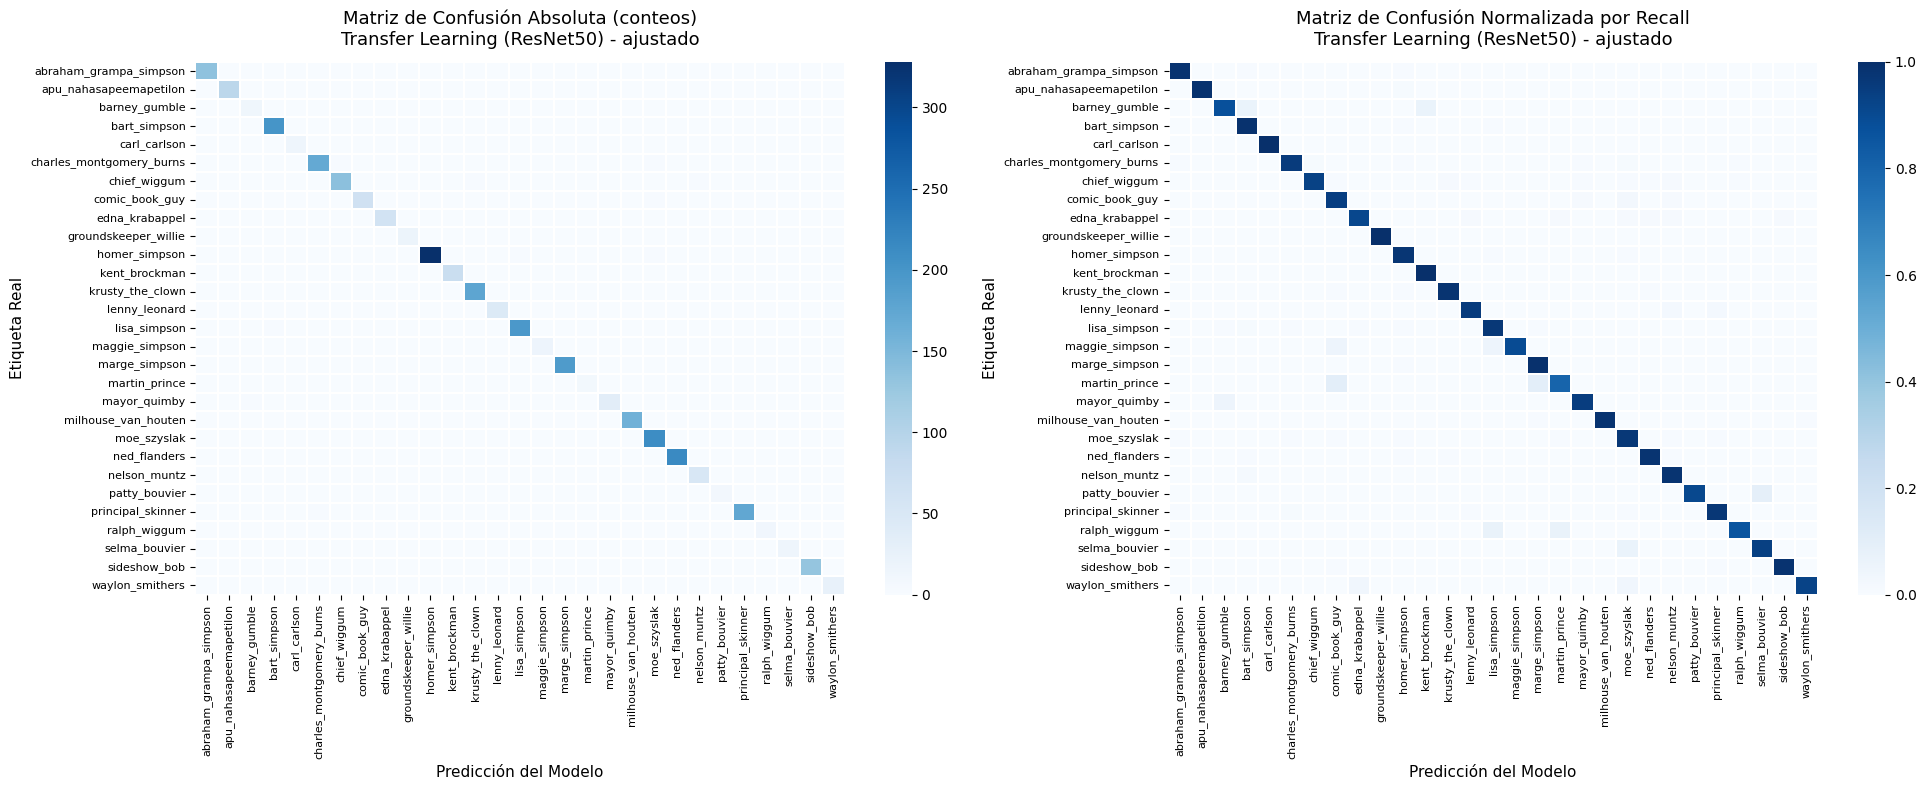

In [ ]:
plot_matrices_confusion(dict_predict_m3b)

In [46]:
def plot_f1_por_clase(dict_predict:dict, ):
    model_name = dict_predict['model_name']
    report_class_names = dict_predict['class_names']
    y_true = dict_predict['y_true']
    y_pred = dict_predict['y_pred']

    # informe clasificacion
    report_dict = classification_report(
        y_true, y_pred, target_names=report_class_names, output_dict=True
    )

    df_report = pd.DataFrame(report_dict).T.iloc[:-3]  # quitar avg rows

    df_sorted = df_report.sort_values('f1-score')
    colors = ['tomato' if v < 0.7 else 'steelblue' for v in df_sorted['f1-score']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(df_sorted) * 0.3)))
    bars = ax.barh(df_sorted.index, df_sorted['f1-score'], color=colors, edgecolor='white', linewidth=0.5)
    
    ax.axvline(0.7, color='orange', linestyle='--', linewidth=1.2, label='F1 = 0.70')
    ax.axvline(0.9, color='green', linestyle='--', linewidth=1.2, label='F1 = 0.90')
    ax.set_xlabel('F1-score', fontsize=12)
    ax.set_title(f'F-1 score por clase — {model_name}', fontsize=14)
    ax.set_xlim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

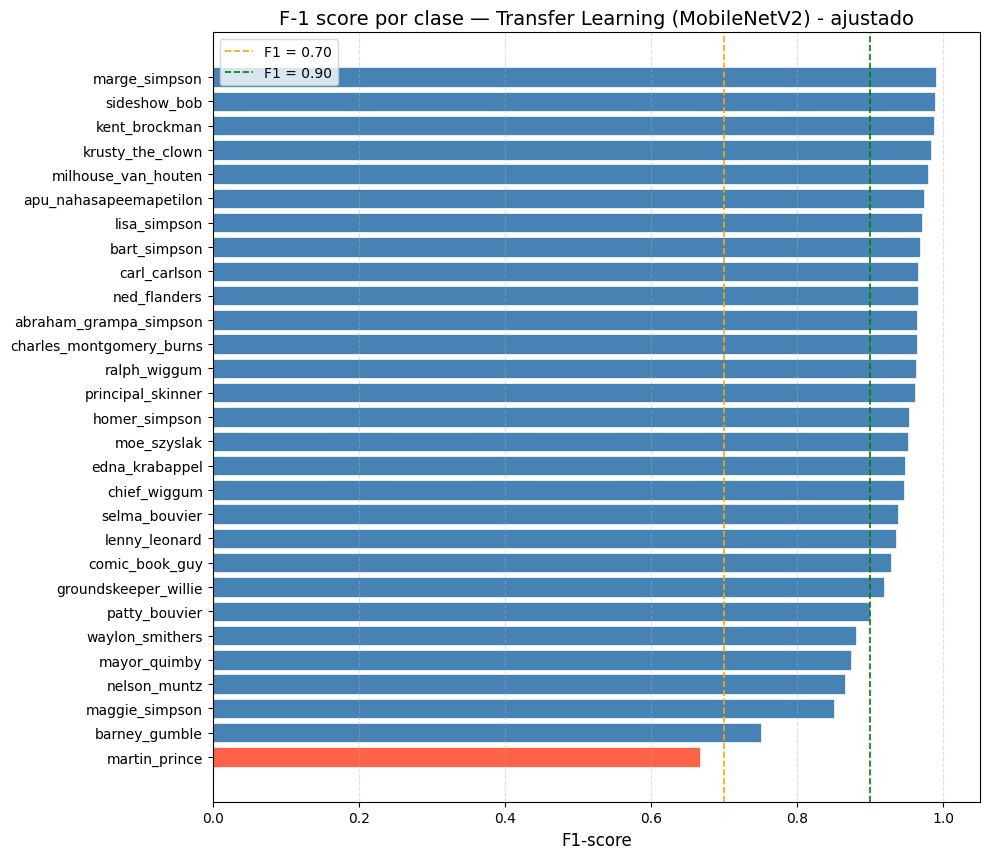

In [48]:
plot_f1_por_clase(dict_predict_m4b)

In [ ]:
def mostrar_top_pares_confundidos(dict_result, top_n: int = 5):
    print(f"\n{'='*80}")
    print(f" PARES MÁS CONFUNDIDOS — {dict_result['model_name']}")
    print(f"{'='*80}")

    cm = confusion_matrix(dict_result['y_true'], dict_result['y_pred'])
    np.fill_diagonal(cm, 0) # Ignoramos los aciertos
    
    flat_idx = np.argsort(cm.ravel())[::-1][:top_n]
    for idx in flat_idx:
        real = idx // len(dict_result['class_names'])
        pred = idx % len(dict_result['class_names'])
        count = cm[real, pred]
        if count > 0:
            print(f"    Real: {dict_result['class_names'][real]:<25} --> "
                  f"Predicho: {dict_result['class_names'][pred]:<25} ({count} veces)")

In [80]:
mostrar_top_pares_confundidos(dict_predict_m4b)


 PARES MÁS CONFUNDIDOS — Transfer Learning (MobileNetV2) - ajustado
    Real: ned_flanders              → Predicho: homer_simpson             (5 veces)
    Real: mayor_quimby              → Predicho: nelson_muntz              (3 veces)
    Real: charles_montgomery_burns  → Predicho: moe_szyslak               (3 veces)
    Real: milhouse_van_houten       → Predicho: bart_simpson              (3 veces)
    Real: bart_simpson              → Predicho: homer_simpson             (2 veces)


In [95]:
def plot_errores_top_pares(dict_predict: dict, test_df: pd.DataFrame,
                            img_col: str = 'filepath', top_n: int = 5,
                            n_cols: int = 4, figsize_per_img: float = 3.0):
    """
    Para cada par del top-N más confundidos, muestra las imágenes mal clasificadas.

    Args:
        dict_predict: salida de obtener_predicciones()
        test_df: DataFrame del conjunto de test
        img_col: columna con la ruta a la imagen
        top_n: número de pares a analizar
        n_cols: columnas en el grid de cada par
        figsize_per_img: tamaño en pulgadas de cada celda
    """
    y_true = np.array(dict_predict['y_true'])
    y_pred = np.array(dict_predict['y_pred'])
    class_names = dict_predict['class_names']
    model_name = dict_predict['model_name']

    # Recalcular top pares confundidos
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    cm_flat = cm.ravel()
    top_idx = [idx for idx in np.argsort(cm_flat)[::-1] if cm_flat[idx] > 0][:top_n]

    for idx in top_idx:
        real_idx = idx // len(class_names)
        pred_idx = idx % len(class_names)
        real_name = class_names[real_idx]
        pred_name = class_names[pred_idx]
        count = cm[real_idx, pred_idx]

        # Índices de imágenes de este par concreto
        mask = (y_true == real_idx) & (y_pred == pred_idx)
        error_idx = np.where(mask)[0]

        print(f"\nReal: {real_name}  →  Predicho: {pred_name}  ({count} imagen/es)")

        n_rows = int(np.ceil(len(error_idx) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(n_cols * figsize_per_img, n_rows * figsize_per_img),
                                  squeeze=False)
        axes = axes.flatten()

        for plot_i, sample_i in enumerate(error_idx):
            img_path = test_df.iloc[sample_i][img_col]
            img = tf.keras.utils.load_img(img_path)
            axes[plot_i].imshow(img)
            axes[plot_i].set_title(f"Real: {real_name}\nPred: {pred_name}",
                                    fontsize=7, color='red', pad=3)
            axes[plot_i].axis('off')

        for j in range(len(error_idx), len(axes)):
            axes[j].axis('off')

        fig.suptitle(f'{model_name} — {real_name} → {pred_name}', fontsize=12, y=1.01)
        plt.tight_layout()
        plt.show()


Real: ned_flanders  →  Predicho: homer_simpson  (5 imagen/es)


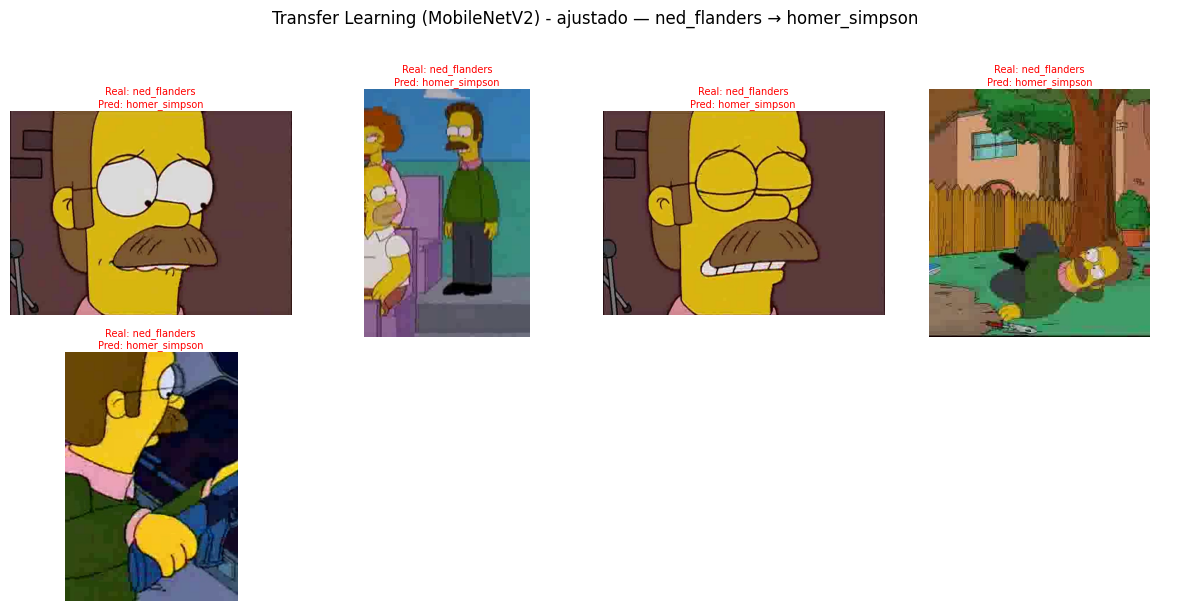


Real: mayor_quimby  →  Predicho: nelson_muntz  (3 imagen/es)


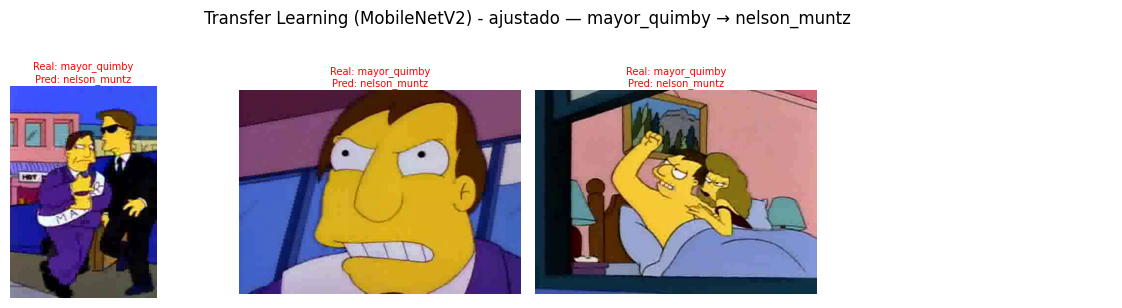


Real: charles_montgomery_burns  →  Predicho: moe_szyslak  (3 imagen/es)


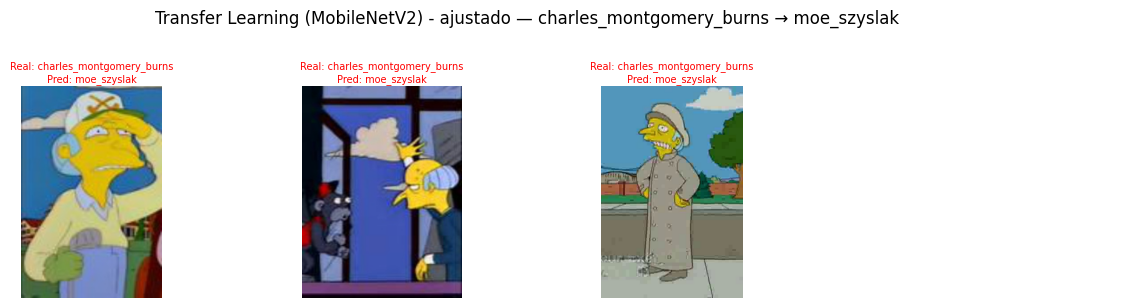


Real: milhouse_van_houten  →  Predicho: bart_simpson  (3 imagen/es)


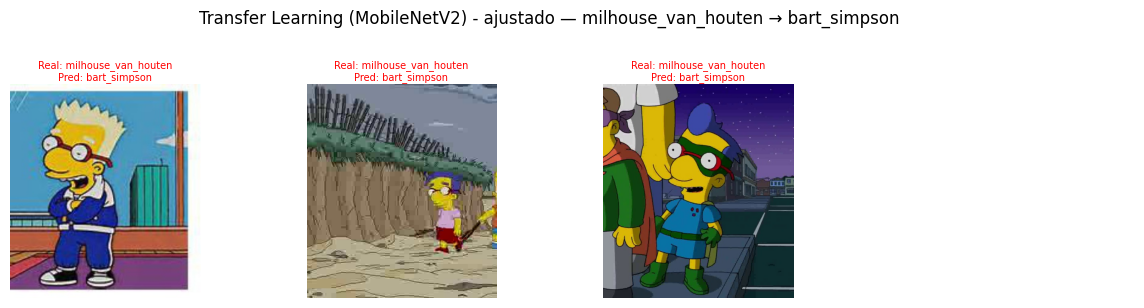


Real: bart_simpson  →  Predicho: homer_simpson  (2 imagen/es)


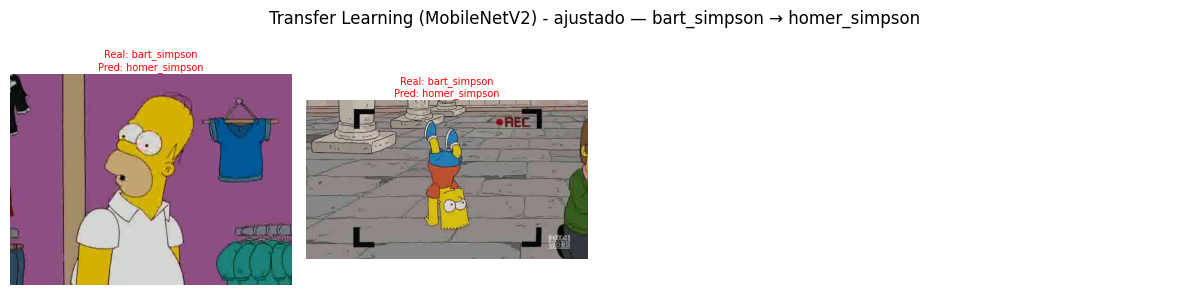

In [96]:
plot_errores_top_pares(dict_predict_m4b, df_test)


Real: mayor_quimby  →  Predicho: barney_gumble  (2 imagen/es)


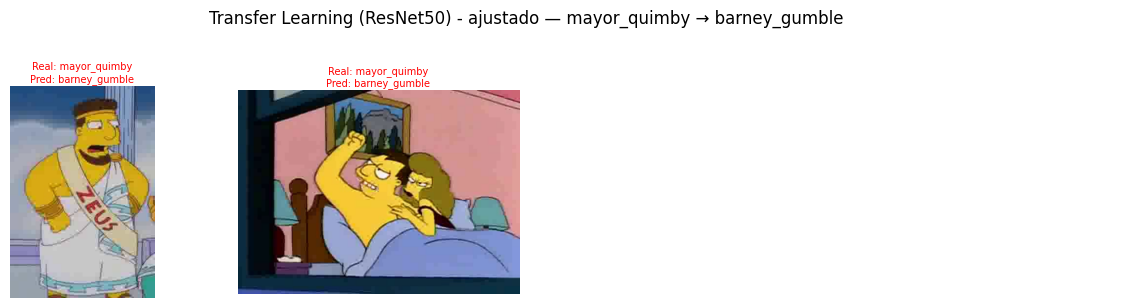


Real: comic_book_guy  →  Predicho: moe_szyslak  (2 imagen/es)


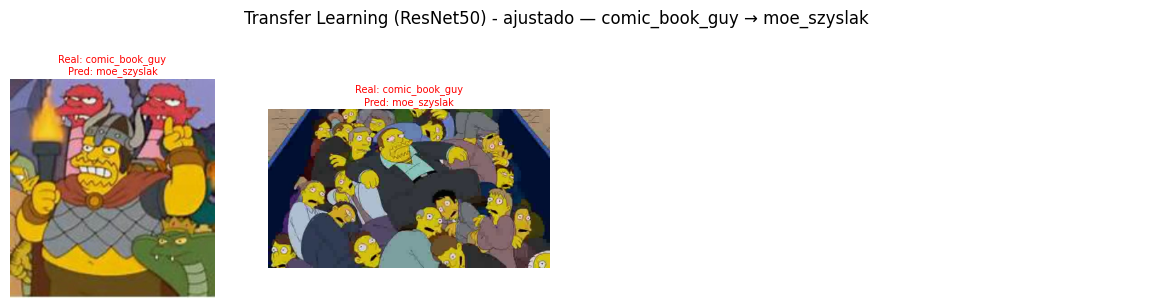


Real: chief_wiggum  →  Predicho: krusty_the_clown  (2 imagen/es)


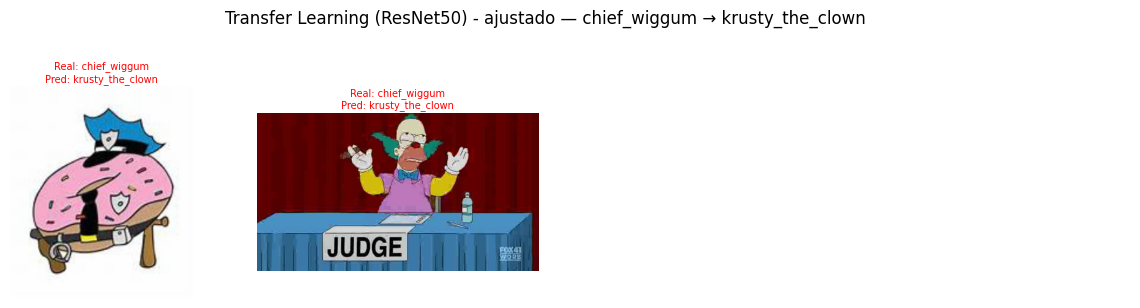


Real: lisa_simpson  →  Predicho: bart_simpson  (2 imagen/es)


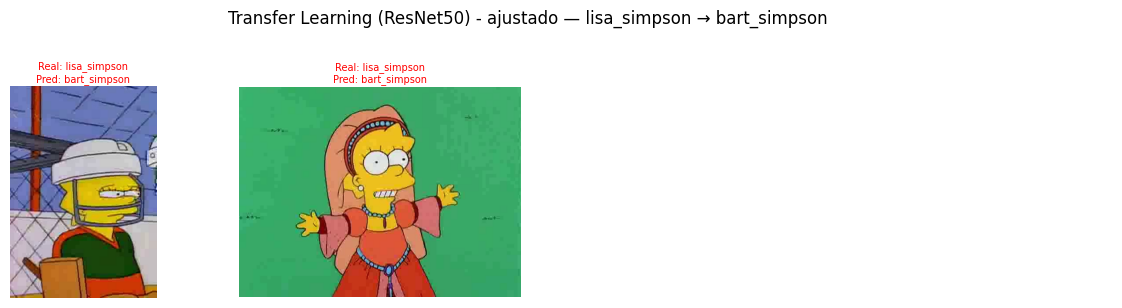


Real: homer_simpson  →  Predicho: lisa_simpson  (2 imagen/es)


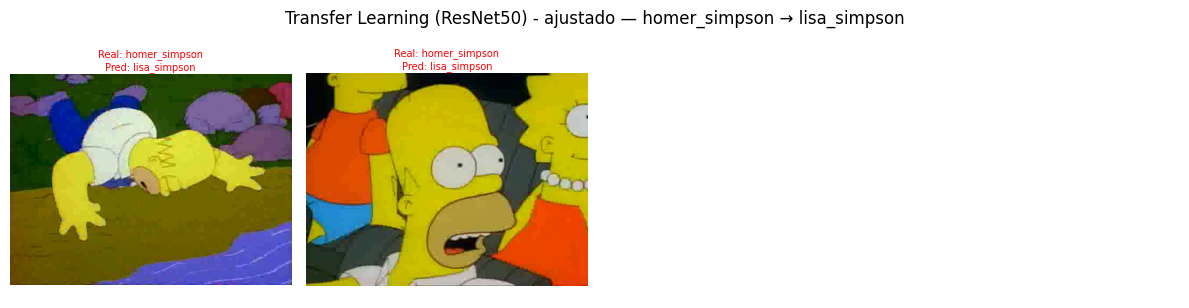

In [97]:
plot_errores_top_pares(dict_predict_m3b, df_test)

In [92]:
print(df_test.columns.tolist())
print(df_test.head(2))

['filepath', 'label']
                                            filepath          label
0  ./simpsons_dataset_strat_split/test/homer_simp...  homer_simpson
1  ./simpsons_dataset_strat_split/test/homer_simp...  homer_simpson



  INFORME EVALUACIÓN — Transfer Learning (ResNet50) - ajustado

  Cargando modelo desde: ./modelos/m3_resnet_ajust.keras
  Generando predicciones sobre 3078 imágenes...

  Test Accuracy : 97.08%
  Test Loss     : 0.1783

────────────────────────────────────────────────────────────
  CLASSIFICATION REPORT
────────────────────────────────────────────────────────────
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.97      0.99      0.98       137
  apu_nahasapeemapetilon       1.00      0.99      0.99        94
           barney_gumble       0.82      0.88      0.85        16
            bart_simpson       0.97      0.99      0.98       202
            carl_carlson       1.00      1.00      1.00        15
charles_montgomery_burns       0.97      0.96      0.96       179
            chief_wiggum       0.99      0.93      0.96       148
          comic_book_guy       0.90      0.94      0.92        70
          edna_krabappel       0.97  

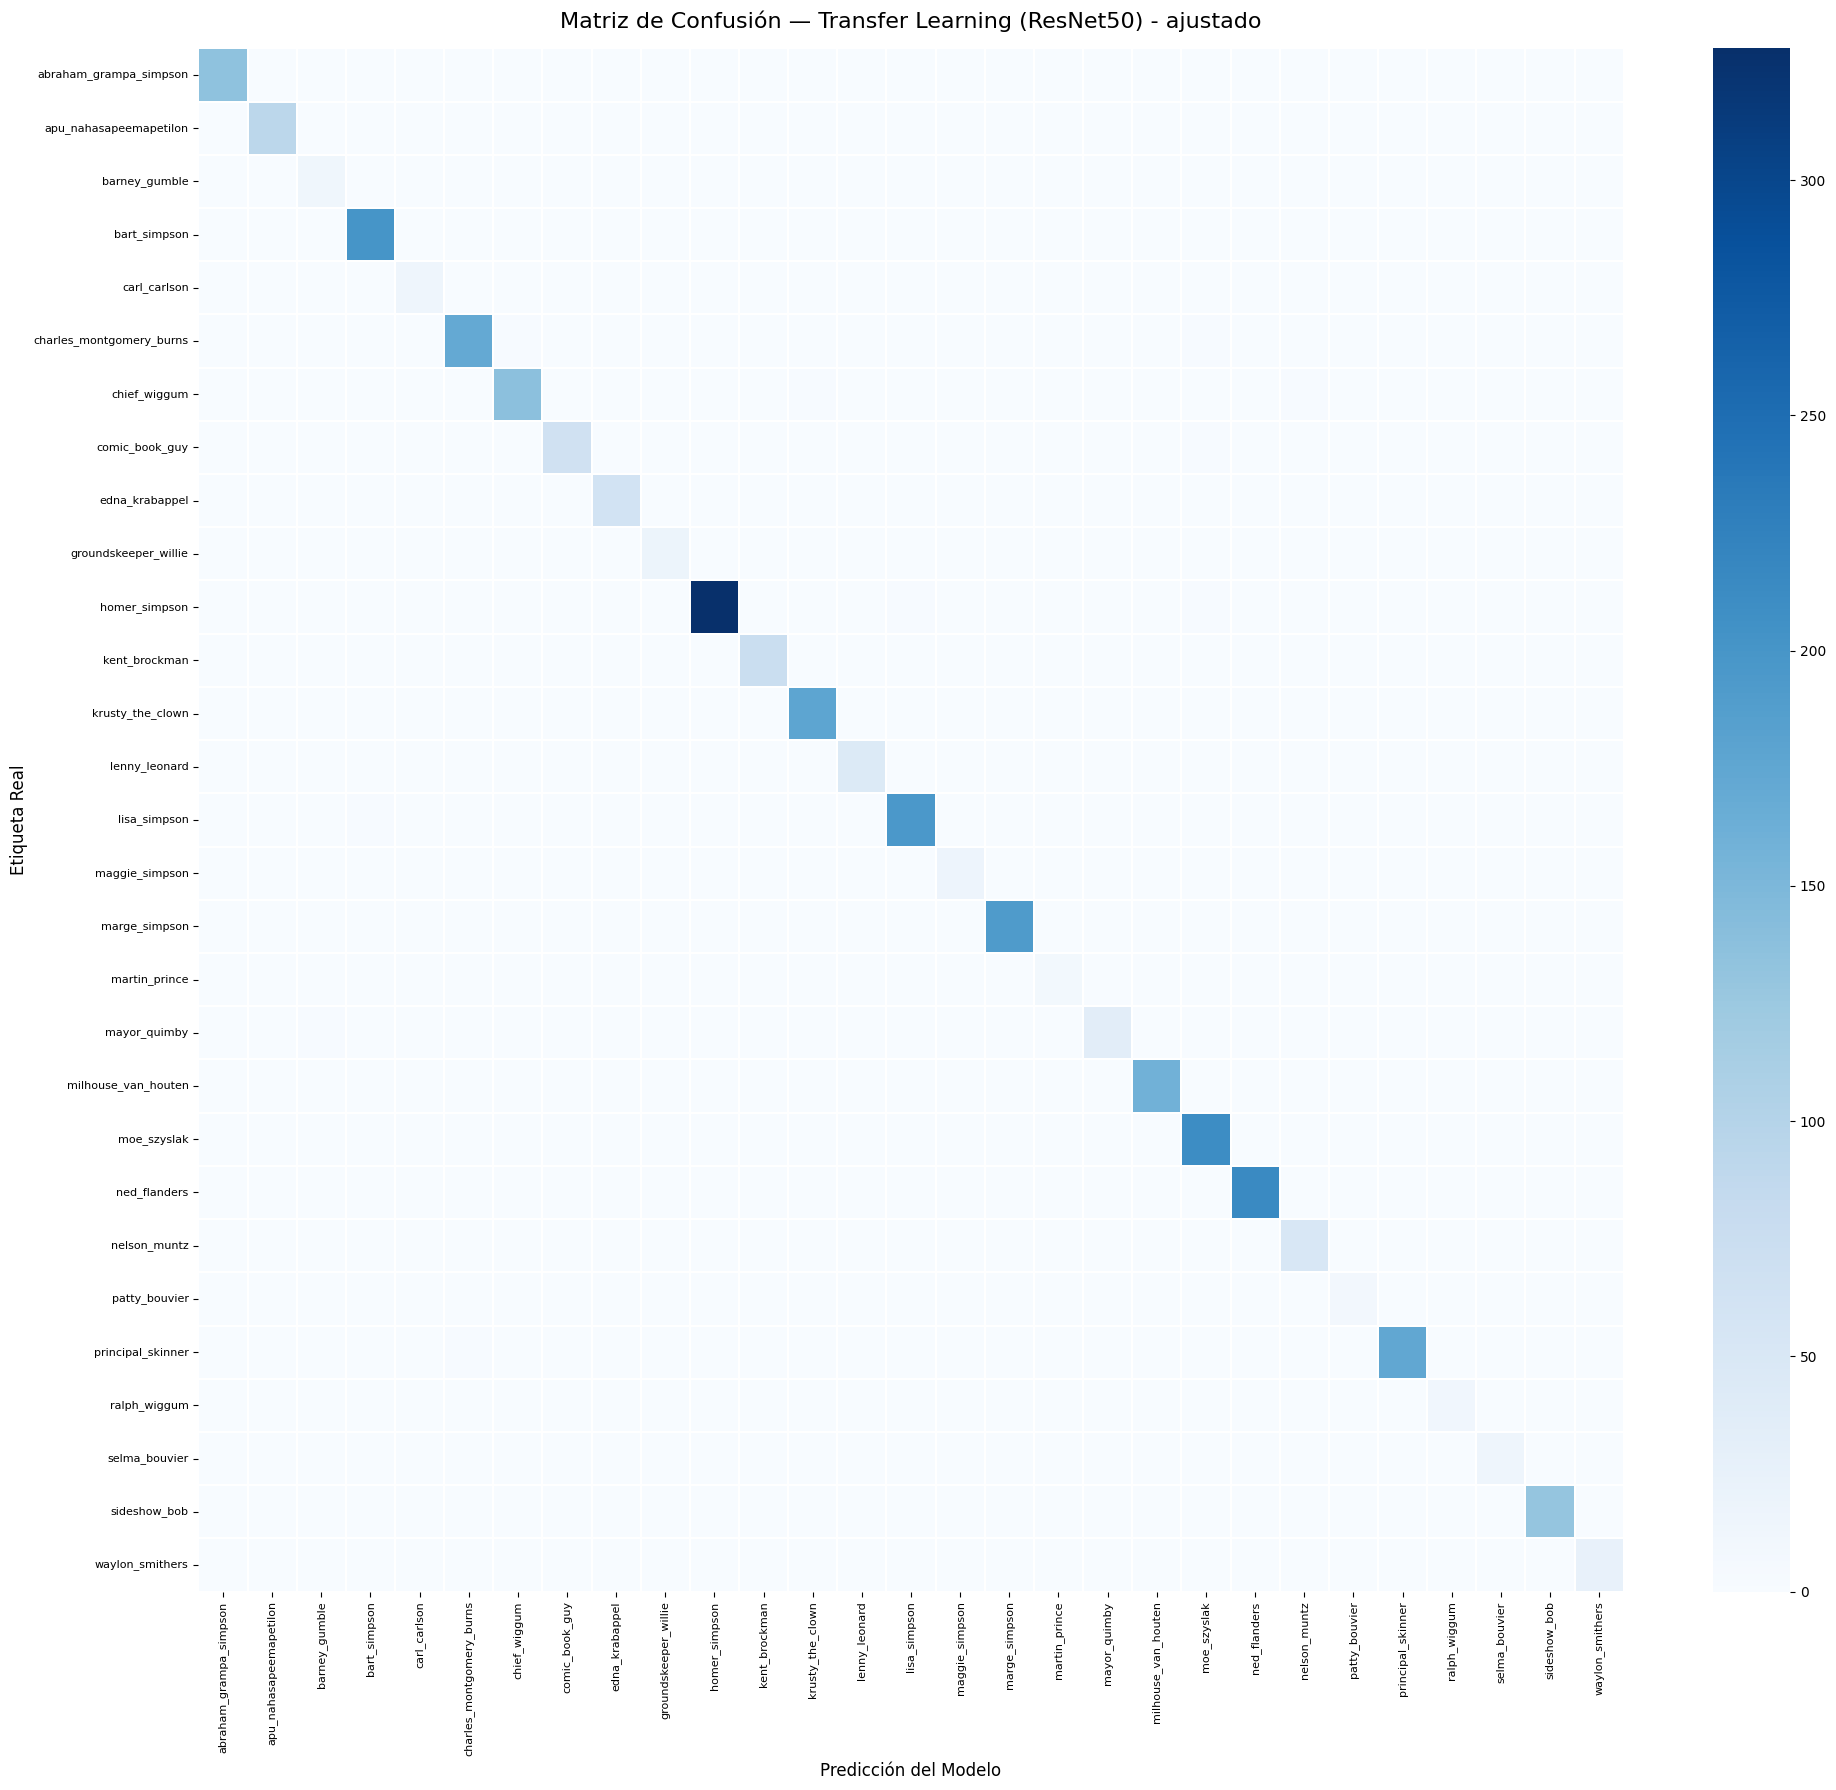


  ── Top 5 clases con PEOR F1-score ──
    martin_prince                   F1=0.7619  P=0.7273  R=0.8000  N=10
    barney_gumble                   F1=0.8485  P=0.8235  R=0.8750  N=16
    ralph_wiggum                    F1=0.8571  P=0.8571  R=0.8571  N=14
    maggie_simpson                  F1=0.9189  P=0.9444  R=0.8947  N=19
    comic_book_guy                  F1=0.9231  P=0.9041  R=0.9429  N=70

  ── Top 5 pares más confundidos ──
    Real: mayor_quimby              → Predicho: barney_gumble              (2 veces)
    Real: comic_book_guy            → Predicho: moe_szyslak                (2 veces)
    Real: chief_wiggum              → Predicho: krusty_the_clown           (2 veces)
    Real: lisa_simpson              → Predicho: bart_simpson               (2 veces)
    Real: homer_simpson             → Predicho: lisa_simpson               (2 veces)


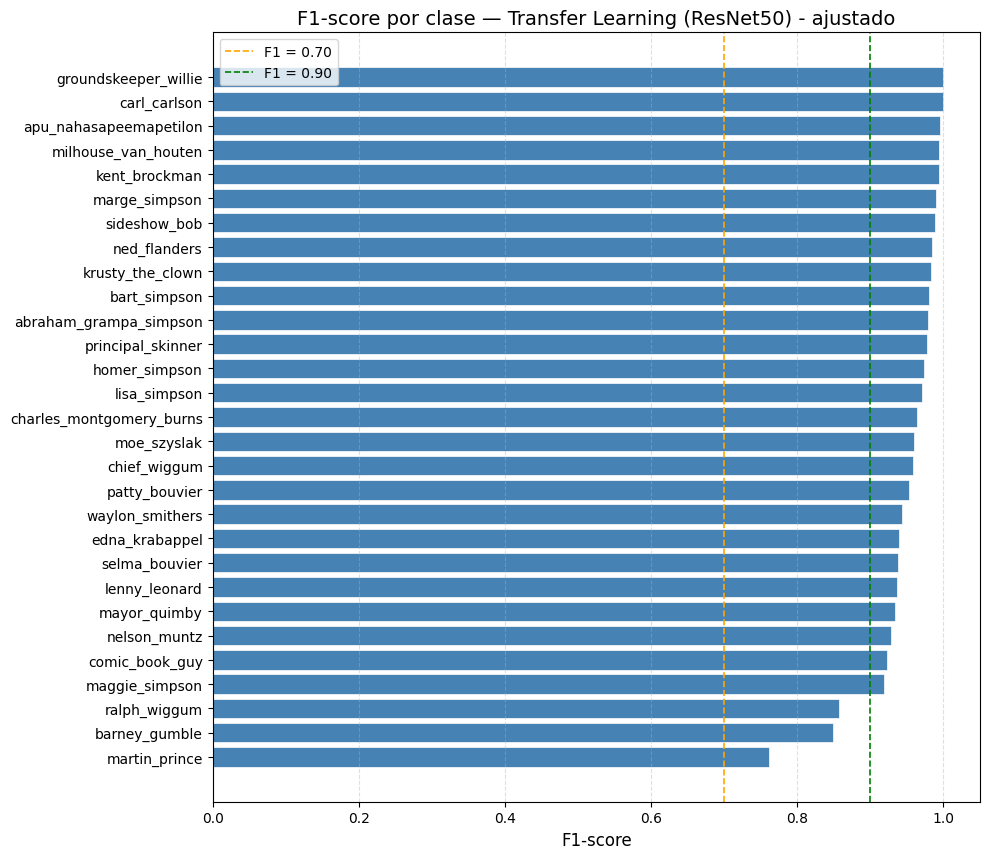


  ✅ Reporte completado — Transfer Learning (ResNet50) - ajustado



{'model': <Sequential name=sequential_7, built=True>,
 'y_true': [10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,


In [41]:
full_model_report(
    model_name = NAME_M3_B,
    model_path = RUTA_M3_B,
    test_gen   = test_gen_resnet_m3b
)


  REPORTE COMPLETO — Transfer Learning (MobileNetV2) - ajustado

  Cargando modelo desde: ./modelos/m4_mobilenet_ajust.keras
  Generando predicciones sobre 3078 imágenes...

  Test Accuracy : 95.81%
  Test Loss     : 0.1894

────────────────────────────────────────────────────────────
  CLASSIFICATION REPORT
────────────────────────────────────────────────────────────
                          precision    recall  f1-score   support

  abraham_grampa_simpson       0.96      0.97      0.96       137
  apu_nahasapeemapetilon       0.97      0.98      0.97        94
           barney_gumble       0.75      0.75      0.75        16
            bart_simpson       0.96      0.98      0.97       202
            carl_carlson       1.00      0.93      0.97        15
charles_montgomery_burns       0.98      0.95      0.96       179
            chief_wiggum       0.95      0.95      0.95       148
          comic_book_guy       0.93      0.93      0.93        70
          edna_krabappel       0.

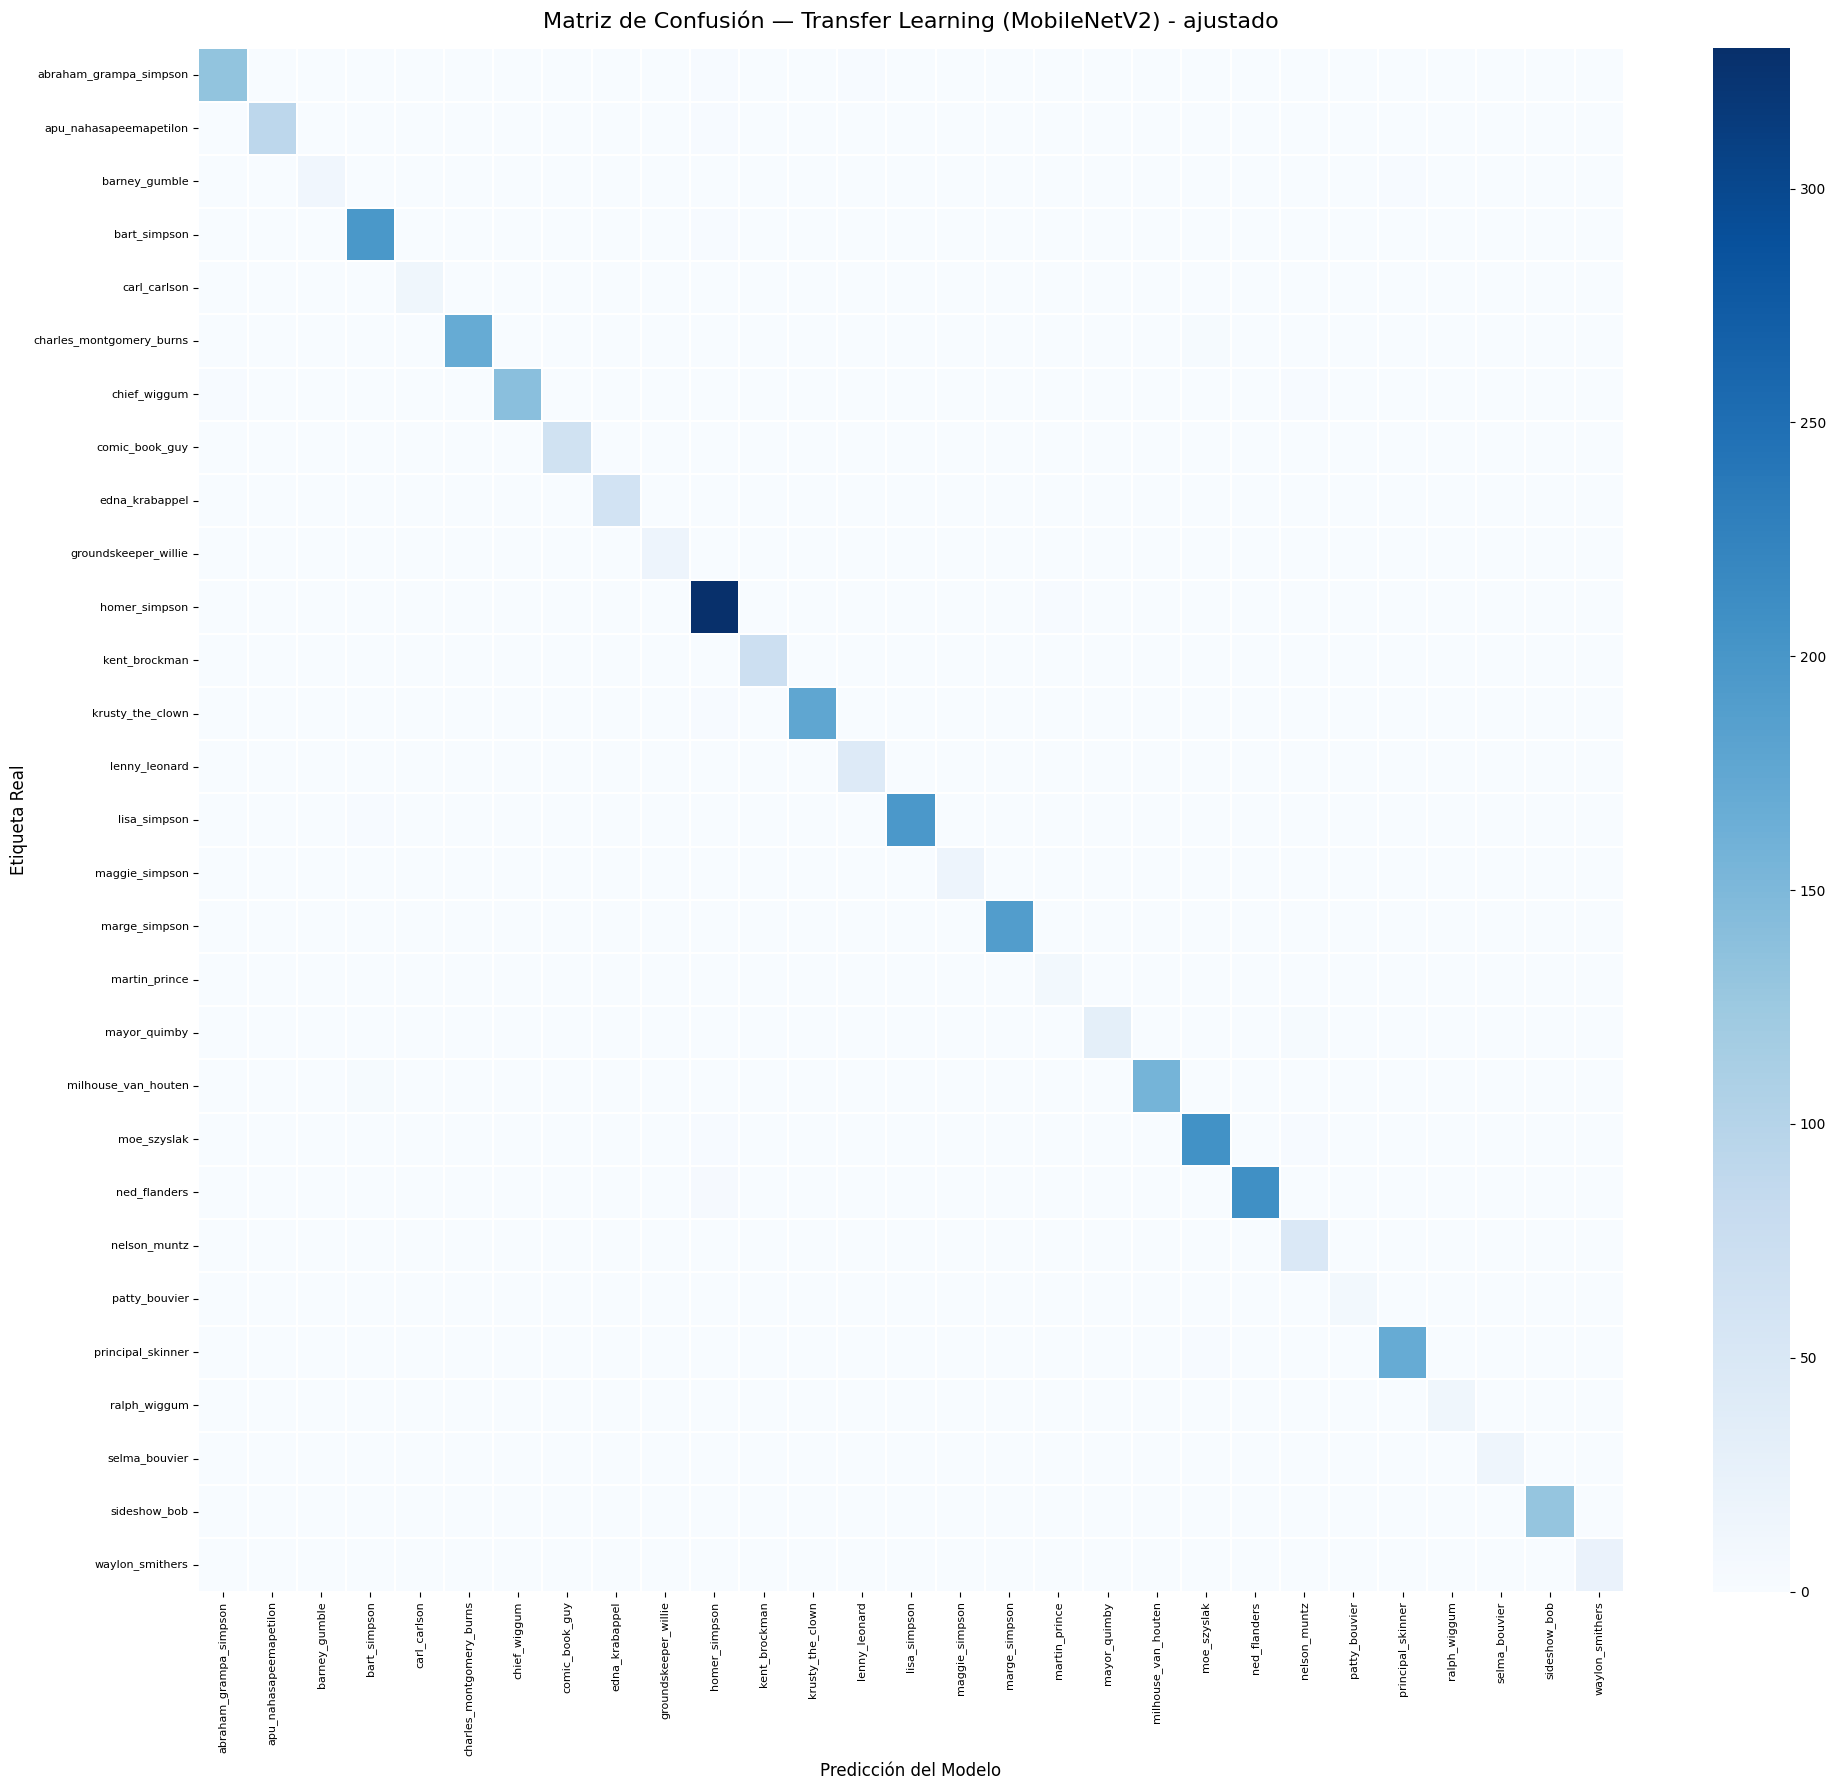


  ── Top 5 clases con PEOR F1-score ──
    martin_prince                   F1=0.667  P=0.571  R=0.800  N=10
    barney_gumble                   F1=0.750  P=0.750  R=0.750  N=16
    maggie_simpson                  F1=0.850  P=0.810  R=0.895  N=19
    nelson_muntz                    F1=0.865  P=0.828  R=0.906  N=53
    mayor_quimby                    F1=0.873  P=0.912  R=0.838  N=37

  ── Top 5 pares más confundidos ──
    Real: ned_flanders              → Predicho: homer_simpson              (5 veces)
    Real: mayor_quimby              → Predicho: nelson_muntz               (3 veces)
    Real: charles_montgomery_burns  → Predicho: moe_szyslak                (3 veces)
    Real: milhouse_van_houten       → Predicho: bart_simpson               (3 veces)
    Real: bart_simpson              → Predicho: homer_simpson              (2 veces)


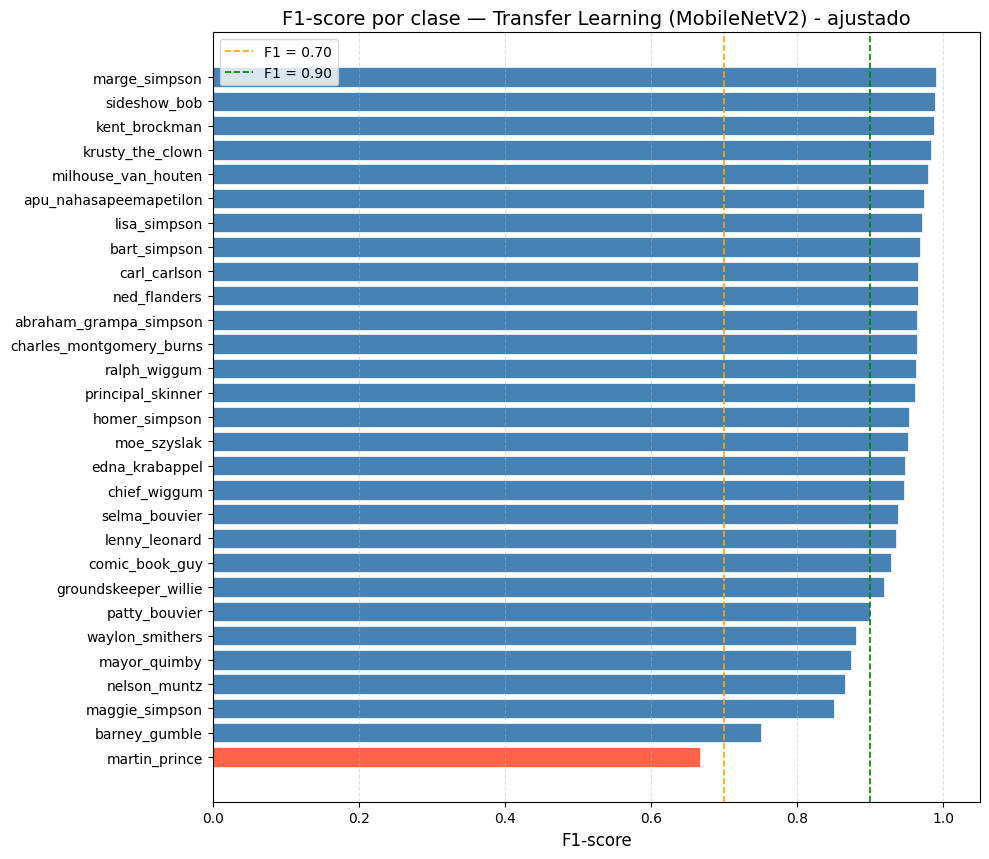


  ✅ Reporte completado — Transfer Learning (MobileNetV2) - ajustado



{'model': <Sequential name=sequential_6, built=True>,
 'y_true': [10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,
  10,


In [ ]:
full_model_report(
    model_name = NAME_M4_B,
    model_path = RUTA_M4_B,
    test_gen   = test_gen_mobilenet_m4b
)

# BLOQUE 2: INFORME

El objetivo de este proyecto es desarrollar clasificadores de imágenes capaces de reconocer personajes de la serie Los Simpsons con una accuracy superior al 90% en el conjunto de test. Para ello, se va a comparar el rendimiento de varios modelos convolucionales, tanto 'desde cero' como preentrenados.

## 1. EDA
En el análisis exploratorio inicial se han identificado los dos principales desafíos del dataset:

### Desafío 1
La variabilidad en las imágenes, extraídas de fotogramas de la serie, con diferentes encuadres, iluminaciones, fondos, múltiples personajes en pantalla, etc.

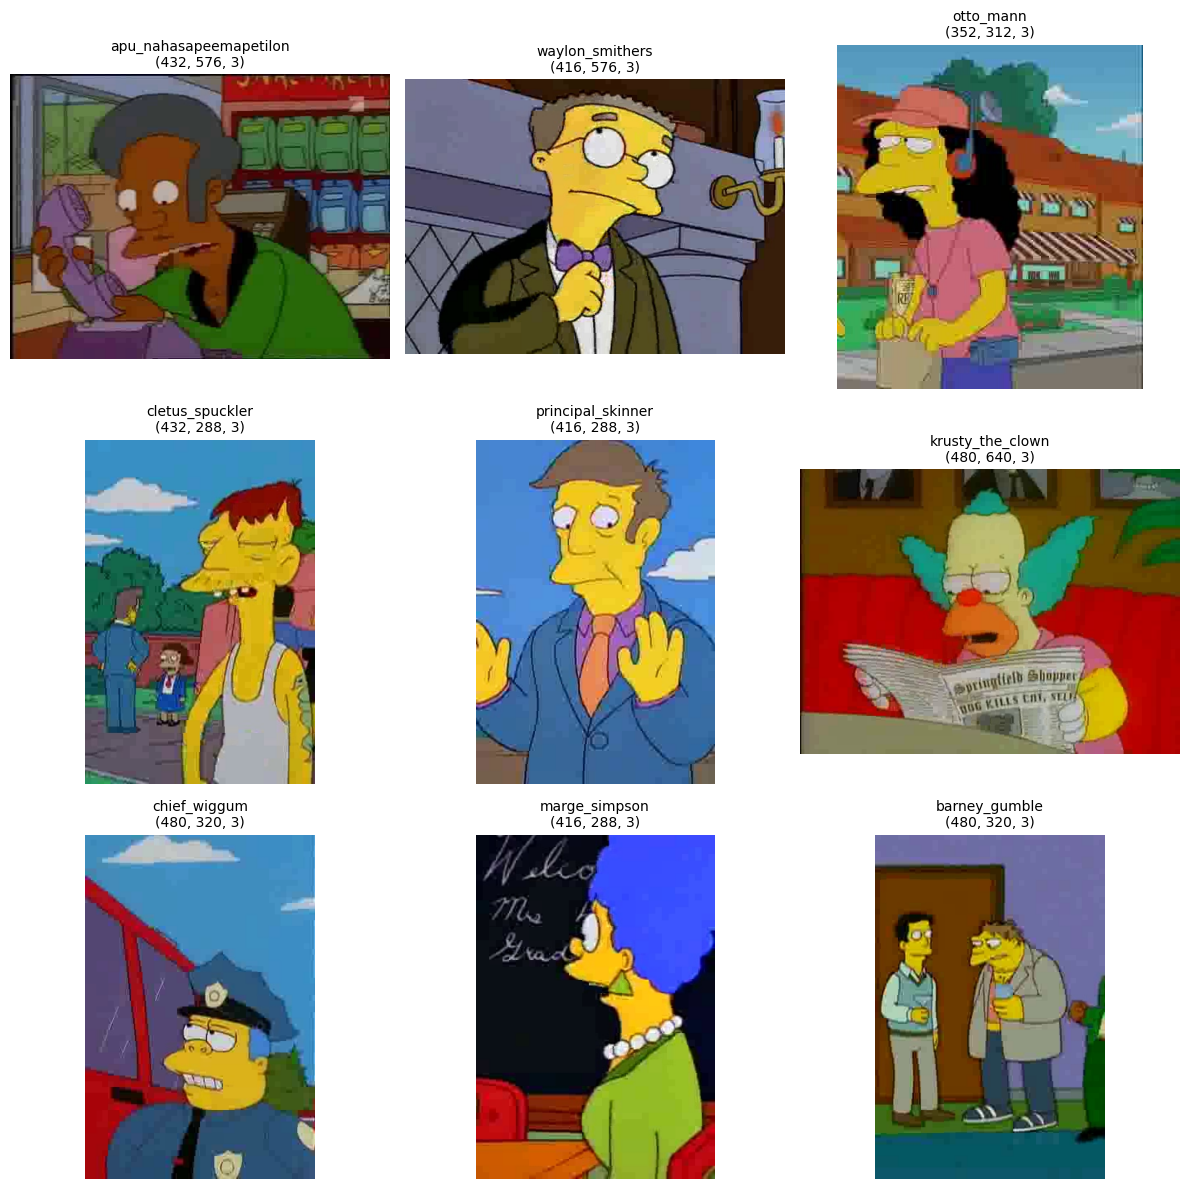

In [9]:
mostrar_imagenes_aleatorias()

Esta dificultad se aborda en el preprocesamiento de las imágenes, aplicando Data Augmentation durante el entrenamiento. Esto permite que el modelo aprenda a reconocer los personajes independientemente de su posición o condiciones de entonro, mejorando su capacidad de generalización.

También se puede observar que las resoluciones de las imágenes varían considerablemente, no todas tienen la misma relación de aspecto:

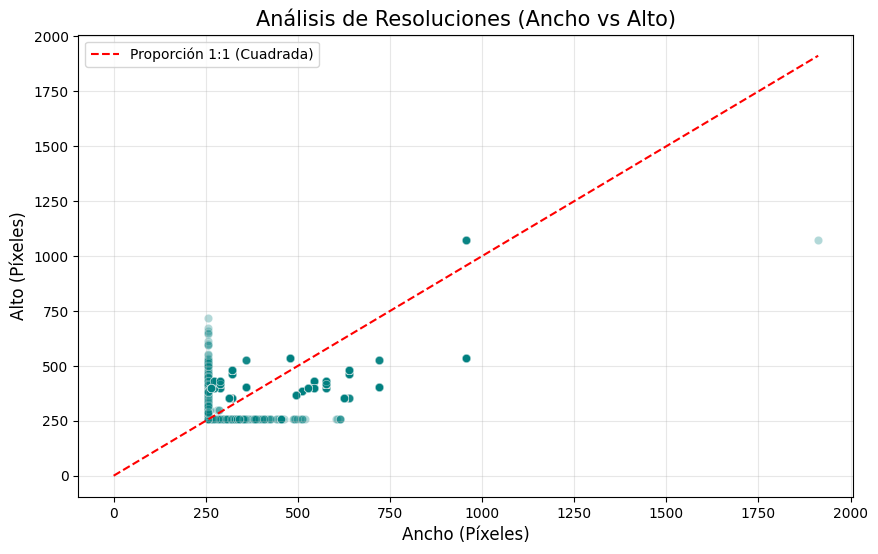

Ancho medio: 409 px | Alto medio: 416 px


In [12]:
problema_resoluciones_imagenes()

Sin embargo, la mayoría de los modelos de CNN requieren entradas de tamaño fijo, por lo que se ha establecido un tamaño de entrada común para todas las imágenes: **160×160 píxeles**. 
  
Aunque se reduce la resolución original y se pierde algo de detalle, teniendo en cuenta las capacidades computacionales disponibles y los tamaños de entrada aceptados por algunos de los modelos preentrenados que se utilizarán (MobileNetV2 solo acepta tamaños de 96, 128, 160, 192 o 224), este formato es el que ofrece el mejor equilibrio entre calidad de representación y consumo. 

### Desafío 2
El dataset presenta un gran desbalanceo de clases, hay personajes principales con miles de imágenes, mientras que otros apenas tienen muestra. Para solucionarlo, se ha establecido un umbral muestral mínimo para descartar del problema de clasificación aquellas clases que no tengan un número suficiente de imágenes en el conjunto de entrenamiento, ya que pueden dificultar el aprendizaje de la red y su capacidad de generalización.

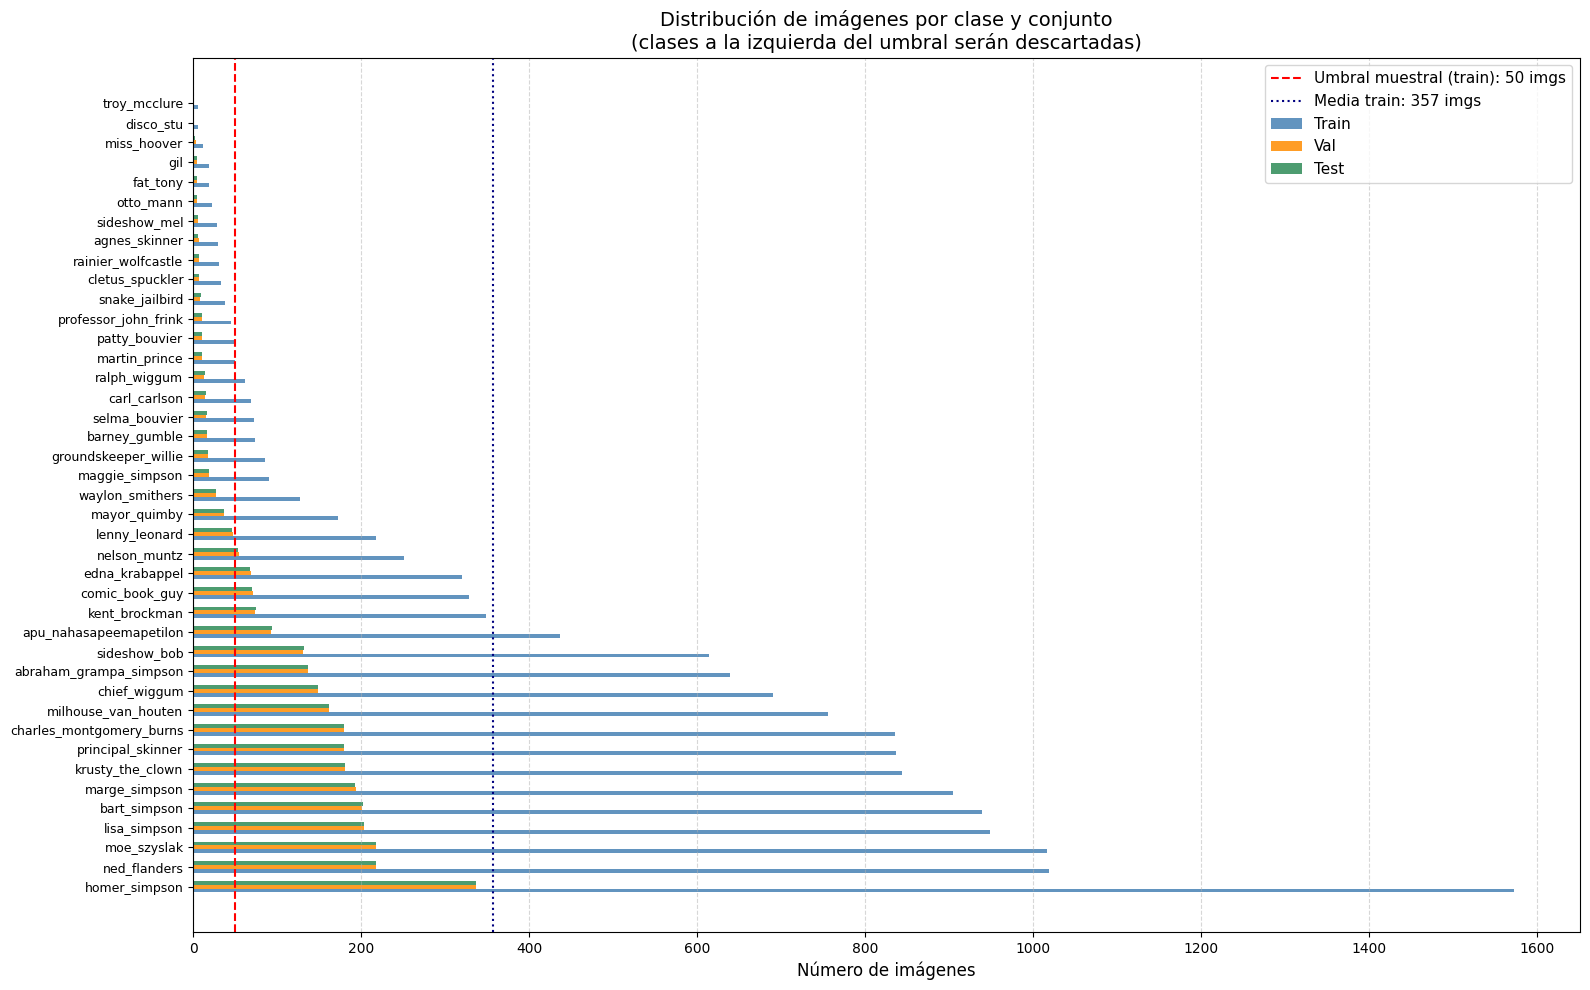


  Total de clases en disco : 41
  Clases viables (≥50)  : 29
  Clases descartadas (<50): 12

  Clases descartadas:
    ✗ professor_john_frink                train= 45  val= 10  test= 10
    ✗ snake_jailbird                      train= 38  val=  8  test=  9
    ✗ cletus_spuckler                     train= 33  val=  7  test=  7
    ✗ rainier_wolfcastle                  train= 31  val=  7  test=  7
    ✗ agnes_skinner                       train= 29  val=  7  test=  6
    ✗ sideshow_mel                        train= 28  val=  6  test=  6
    ✗ otto_mann                           train= 22  val=  5  test=  5
    ✗ fat_tony                            train= 19  val=  4  test=  4
    ✗ gil                                 train= 19  val=  4  test=  4
    ✗ miss_hoover                         train= 12  val=  3  test=  2
    ✗ disco_stu                           train=  6  val=  1  test=  1
    ✗ troy_mcclure                        train=  6  val=  1  test=  1



In [20]:
identificar_clases_viables(TRAIN_DIR, VAL_DIR, TEST_DIR, umbral=UMBRAL_MUESTRAL_TRAIN, devolver=False)

## 2. Metodología

### 2.1 Split estratificado 
También en relación al problema de desbalanceo, se ha realizado una mejora metodológica en la partición de los datos. Se ha aplicado un split estratificado de 70% Train / 15% Val / 15% Test, unido a un workflow para descartar las clases con muestra por debajo del umbral. Este procedimiento garantiza que la distribución de clases en cada partición es representativa de la distribución global, esencial para obtener métricas de evaluación fiables.



### 2.2 Preprocesamiento de imágenes
Dado que se entrenan múltiples modelos con distintas arquitecturas, cada una requiere su propio preprocesamiento:
- Para el modelo Fully Connected y la CNN desde cero, la normalización se realizó escalando los píxeles al rango [0, 1]
- Para los modelos preentrenados (ResNet50 y MobileNetV2), se utilizaron las función de preprocesamiento específica de cada uno (``resnet_preprocess``, ``mobilenet_preprocess `` respectivamente), que normalizaN las imágenes según los parámetros con los que fueron entrenados originalmente en ImageNet.


Se aplicó un generador de datos específico a cada modelo, con su correspondiente preprocesamiento, y se aplicó Data Augmentation:
- rotaciones
- desplazamientos horizontales y verticales
- distorsión y zoom para compensar las variaciones de aspect ratio
- volteo horizontal

## 3. Modelos


### 3.1 Arquitecturas comparadas
Se han explorado un total de 6 arquitecturas diferentes:

#### 1. **Fully Connected** 
3 capas densas (512 → 256 → 128), el baseline de la comparativa.

In [52]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 76800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    39,322,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,490,077 (150.64 MB)

 Trainable params: 39,490,077 (150.64 MB)

 Non-trainable params: 0 (0.00 B)

#### 2. **CNN 'desde cero'**
3 bloques convolucionales (32 → 64 → 128 filtros) con BatchNormalization, MaxPooling y regularización, finaliza con una capa densa para clasificación.

In [54]:
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,652,125 (25.38 MB)

 Trainable params: 6,651,421 (25.37 MB)

 Non-trainable params: 704 (2.75 KB)

#### 3. **ResNet50 'a saco'**: 
Transfer Learning directo usando el modelo ResNet50 como extractor de características, dejando intactos los pesos originales del modelo preentrenado con ImageNet.

In [55]:
model_3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,653,725 (94.05 MB)

 Trainable params: 1,064,989 (4.06 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

#### 4. **ResNet50 ajustado**
Dado que estamos tratando con dibujos animados, no con imágenes 'reales', es posible que las características aprendidas por ResNet50 en ImageNet no sean del todo óptimas para este problema. Por ello, se ha probado a modificar la arquitectura de ResNet50 descongelando las últimas capas convolucionales (bloques conv4 y conv5) para que puedan adaptarse mejor a las características específicas de los personajes de los Simpsons.

In [56]:
model_3_bis.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 29)             │        14,877 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,651,677 (94.04 MB)

 Trainable params: 23,171,613 (88.39 MB)

 Non-trainable params: 1,480,064 (5.65 MB)

#### 5. **MobileNetV2 'a saco'**
Otro modelo preentrenado en ImageNet, pero con una arquitectura más ligera que ResNet50.

In [57]:
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,397 (9.90 MB)

 Trainable params: 335,901 (1.28 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

#### 6. **MobileNetV2 ajustado** 
Al igual que con ResNet50, se ha probado a modificar la arquitectura de MobileNetV2 descongelando las últimas capas convolucionales (a partir de la capa 100) para adaptarlas mejor al problema específico de imágenes de dibujos animados.

In [58]:
model_4_bis.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,397 (9.90 MB)

 Trainable params: 2,175,517 (8.30 MB)

 Non-trainable params: 418,880 (1.60 MB)

### 3.2 Comparativa de resultados en validación
Siguiendo el estándar metodológico en ciencia de datos se comparan los modelos usando exclusivamente los datos de validación, el conjunto de test se reserva para la evaluación final de los mejores modelos obtenidos con el fin de evitar data leakage.

In [34]:
mostrar_resultados_validacion()


Resumen de resultados en validación:


,val_accuracy,val_loss,params
Transfer Learning (ResNet50) - ajustado,97.69%,0.1371,"24,651,677.0"
Transfer Learning (MobileNetV2) - ajustado,96.39%,0.1632,"2,594,397.0"
CNN,89.60%,0.4120,"6,652,125.0"
Transfer Learning (ResNet50),81.51%,0.7106,"24,653,725.0"
Transfer Learning (MobileNetV2),68.87%,1.1448,"2,594,397.0"
Fully Connected,10.95%,3.0264,"39,490,077.0"


- Claramente el modelo Fully Connected no es adecuado para este tipo de problema, con estos resultados se demuestra que cuando se trata con imágenes es necesario usar capas convolucionales para conseguir capturar sus características.

- Por su parte el modelo CNN, aunque no es tan sofisticado como los modelos preentrenados, es capaz de aprender características específicas de los dibujos animados y generalizar bastante bien, quedando cerca del 90% de accuracy.

- Los modelos preentrenados con pesos congelados (ResNet50 y MobileNetV2 'a saco') no obtienen resultados muy buenos. Esto confirma las sospechas, como estos modelos se han entrenado con imágenes realistas, utilizarlos directamente para clasificar dibujos animados no es acertado. Aunque son capaces de extraer características, no consiguen capturar bien las particularidades de los personajes de los Simpsons y no llegan a generalizar del todo bien en este dominio visual distinto.

- Sin embargo, al adaptar parte de la arquitectura de los modelos preentrenados descongelando las últimas capas, se consigue un salto cualitativo considerable. Tanto MobileNetV2 como ResNet50 ajustados logran resultados excelentes, con una precisión superior al 95%.


## 4. Evaluación final en test
Los modelos con mejores resultados en validación se han evaluado sobre el conjunto de test:
- ResNet50 ajustado
- MobileNetV2 ajustado



In [30]:
display(df_test_results)

,accuracy,precision,recall,f1-score
model,,,,
Transfer Learning (ResNet50) - ajustado,97.08%,95.03%,95.18%,95.06%
Transfer Learning (MobileNetV2) - ajustado,95.81%,93.30%,92.68%,92.83%


Consiguiendo resultados en la línea de los obtenidos en validación, esto es señal de que no se ha producido overfitting y que estos modelos generalizan bien con datos no vistos.

### El 2º mejor modelo
Con un accuracy por encima del 95% en test y un f1-score de ~93%, el modelo **MobileNetV2 ajustado** demuestra una excelente capacidad de clasificación de los personajes de los Simpsons. 

Sin embargo, aunque las métricas globales son muy buenas, si se estudia el rendimiento por clase podemos observar que hay margen de mejora en la generalización de algunos personajes secundarios:

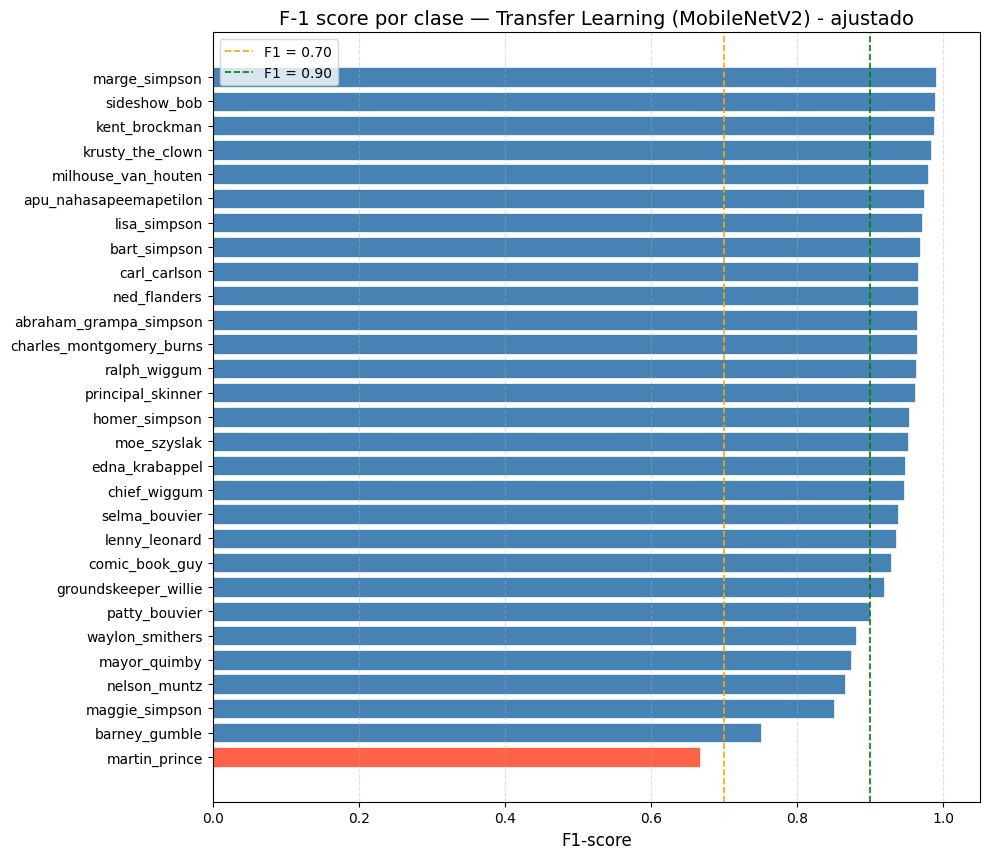

In [49]:
plot_f1_por_clase(dict_predict_m4b)

Si estudiamos más a fondo los errores de clasificación de este modelo:

In [99]:
mostrar_top_pares_confundidos(dict_predict_m4b)


 PARES MÁS CONFUNDIDOS — Transfer Learning (MobileNetV2) - ajustado
    Real: ned_flanders              → Predicho: homer_simpson             (5 veces)
    Real: mayor_quimby              → Predicho: nelson_muntz              (3 veces)
    Real: charles_montgomery_burns  → Predicho: moe_szyslak               (3 veces)
    Real: milhouse_van_houten       → Predicho: bart_simpson              (3 veces)
    Real: bart_simpson              → Predicho: homer_simpson             (2 veces)



Real: ned_flanders  →  Predicho: homer_simpson  (5 imagen/es)


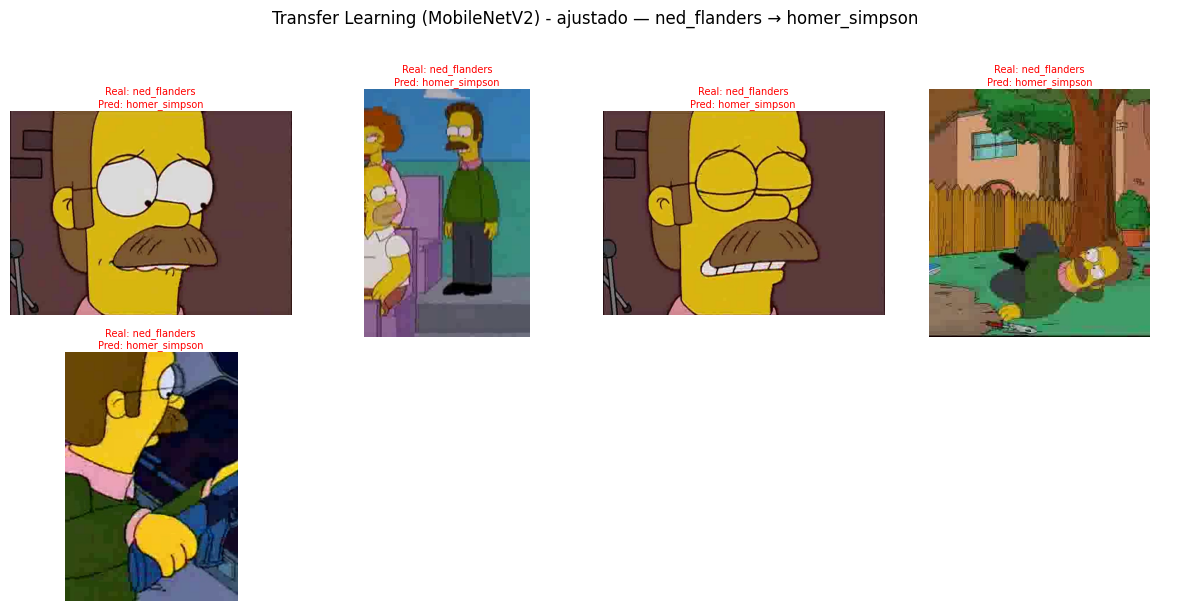


Real: mayor_quimby  →  Predicho: nelson_muntz  (3 imagen/es)


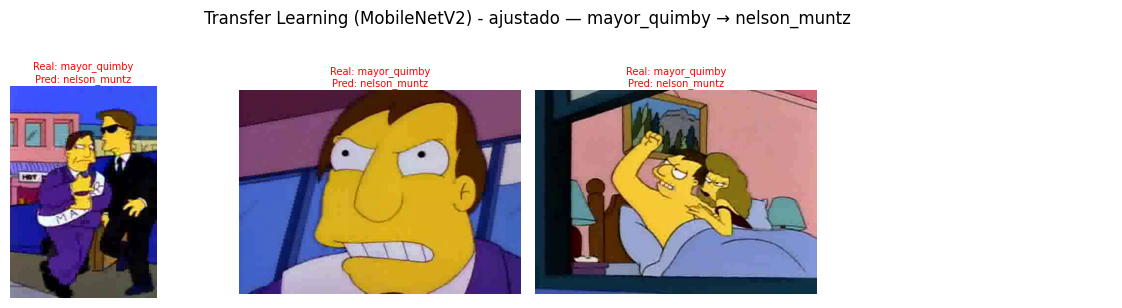


Real: charles_montgomery_burns  →  Predicho: moe_szyslak  (3 imagen/es)


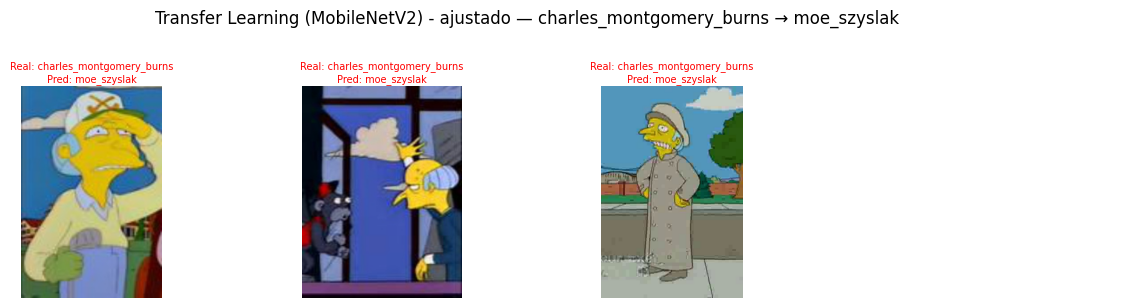


Real: milhouse_van_houten  →  Predicho: bart_simpson  (3 imagen/es)


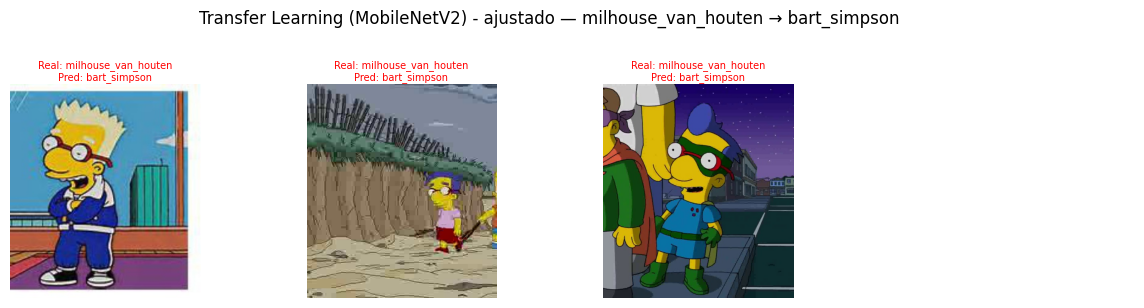


Real: bart_simpson  →  Predicho: homer_simpson  (2 imagen/es)


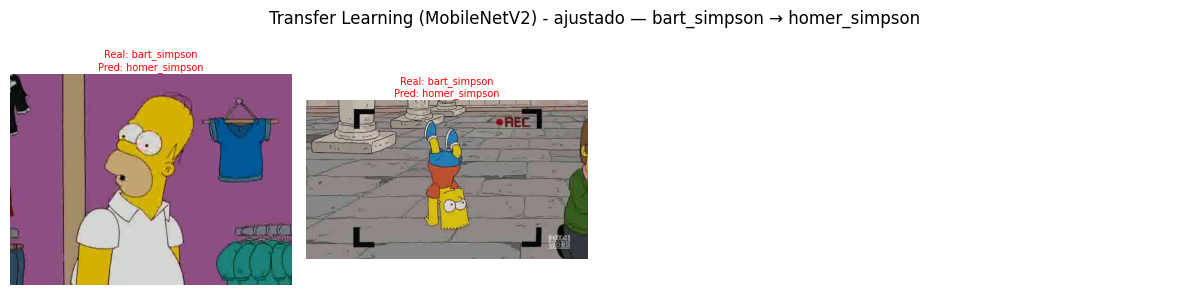

In [100]:
plot_errores_top_pares(dict_predict_m4b, df_test)

Parece ser que:
- o bien, son errores en el etiquetado original (primera foto clasificada como Bart)
- o aparecen varios personajes en el frame, por lo que el modelo puede confundirse sobre cuál es el personaje predominante a clasificar (Ned Flanders y Homer, Milhouse y Bart)
- o bien el personaje está disfrazado, o en una indumentaria fuera de lo habitual que puede generar confusión con otros personajes (Milhouse disfrazado, Mr. Burns con ropa de golf)

Aún así, los errores son residuales y no parecen seguir un patrón claro que indique una debilidad estructural del modelo, sino casos puntuales que podrían solventarse con imágenes más limpias, correctamente etiquetadas o con un mayor número de imágenes de entrenamiento para esos personajes secundarios.

### El modelo ganador
El 1º premio se lo lleva el modelo **ResNet50 ajustado**, con un 97% de accuracy y un f1-score de ~95%. Este modelo ha obtenido entre los estudiados el mejor rendimiento tanto en validación como en test, demostrando una gran capacidad de generalización y adaptación al dominio visual de los Simpsons.

No solo en las métricas globales, también en el análisis por clase, el modelo ResNet50 ajustado obtiene mejores resultados que MobileNetV2 ajustado, con un rendimiento más consistente entre las distintas clases y un f1-score superior al 90% en la mayoría.

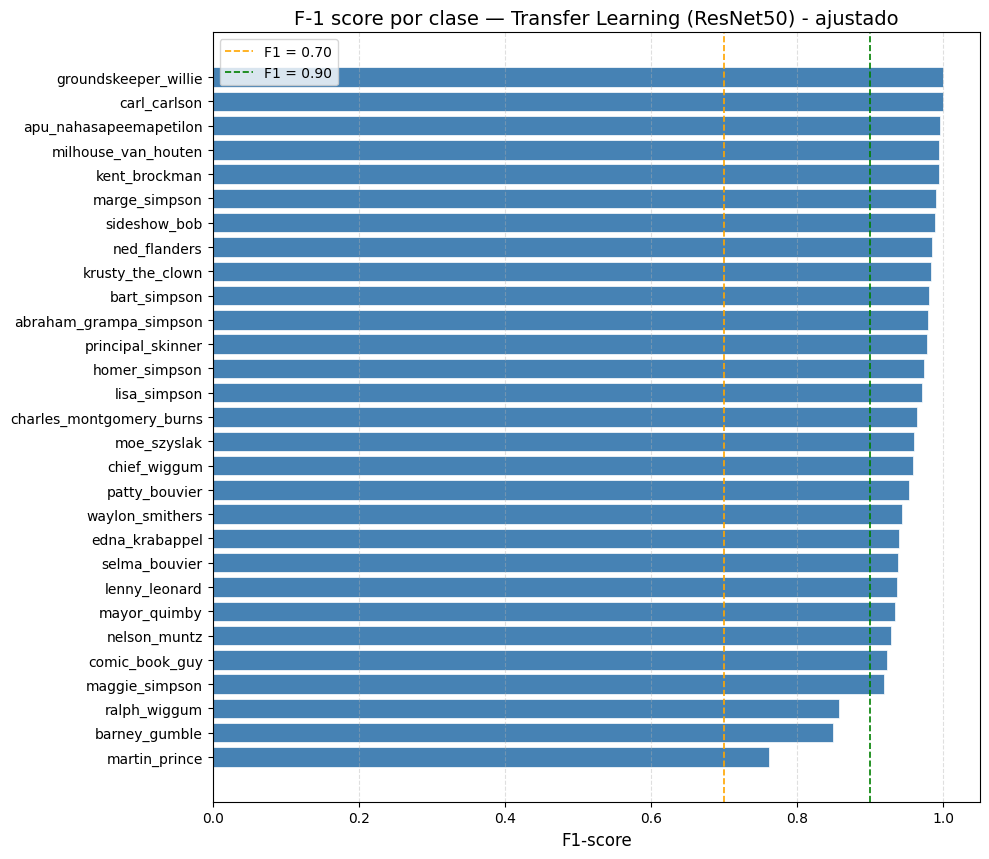

In [51]:
plot_f1_por_clase(dict_predict_m3b)

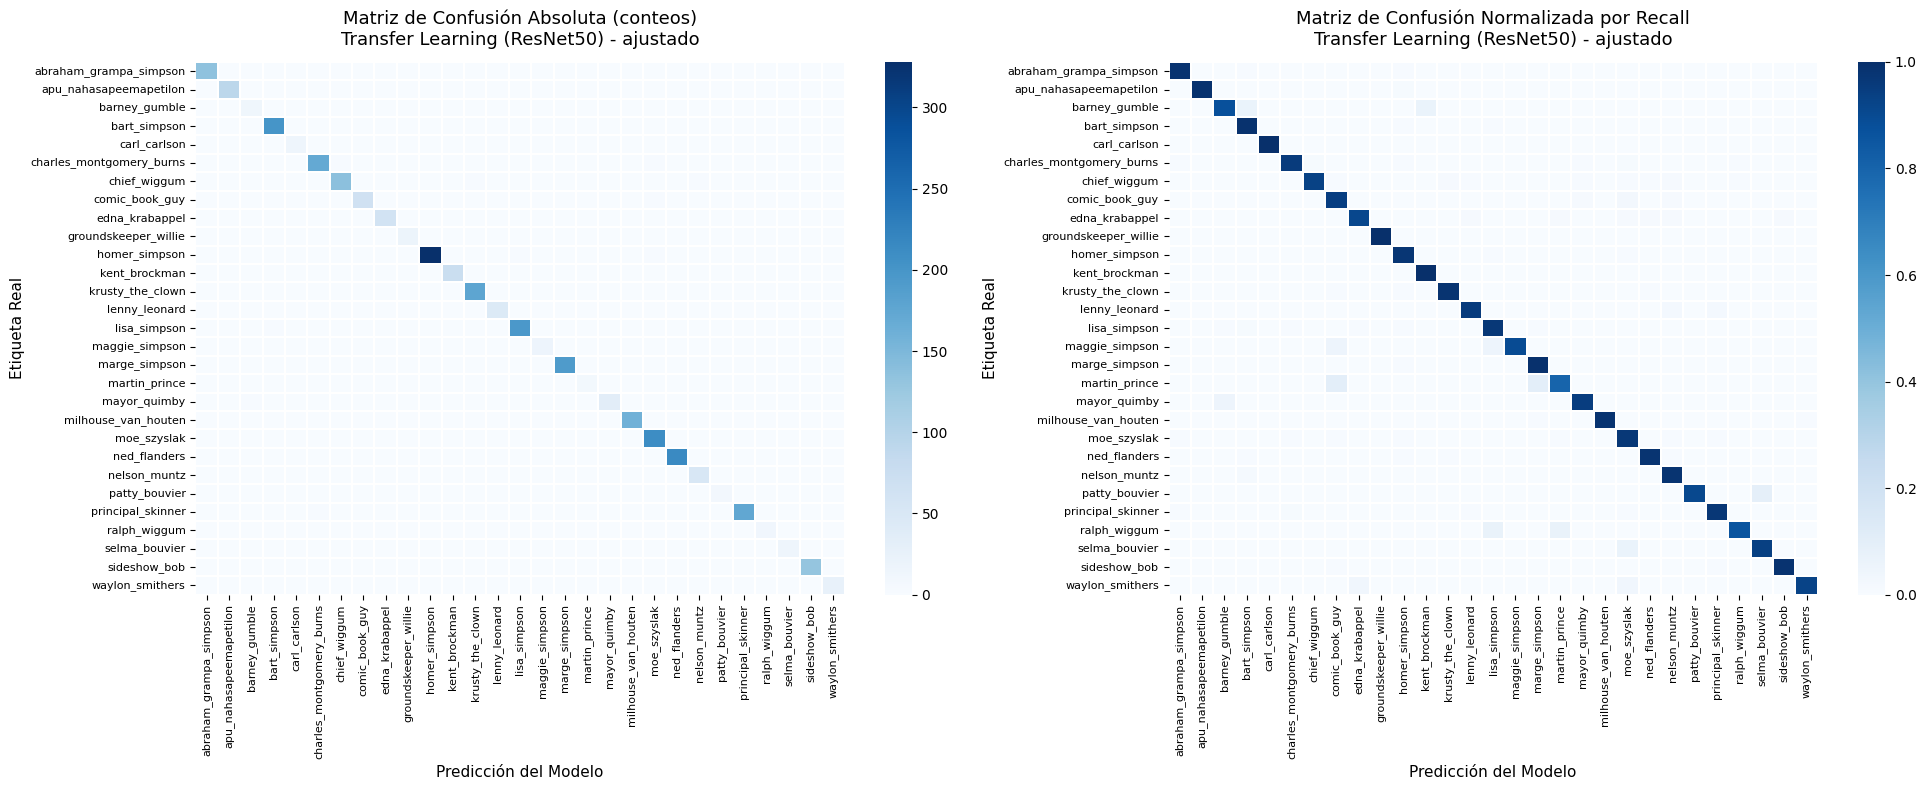

In [ ]:
plot_matrices_confusion(dict_predict_m3b)

El análisis de errores en la clasificación con este modelo nos muestra otra vez que se trata de confusiones puntuales:
- personajes sin su atuendo habitual
- errores en el etiquetado original (Krusty)
- múltiples personajes en la imagen

In [89]:
mostrar_top_pares_confundidos(dict_predict_m3b)


 PARES MÁS CONFUNDIDOS — Transfer Learning (ResNet50) - ajustado
    Real: mayor_quimby              → Predicho: barney_gumble             (2 veces)
    Real: comic_book_guy            → Predicho: moe_szyslak               (2 veces)
    Real: chief_wiggum              → Predicho: krusty_the_clown          (2 veces)
    Real: lisa_simpson              → Predicho: bart_simpson              (2 veces)
    Real: homer_simpson             → Predicho: lisa_simpson              (2 veces)



Real: mayor_quimby  →  Predicho: barney_gumble  (2 imagen/es)


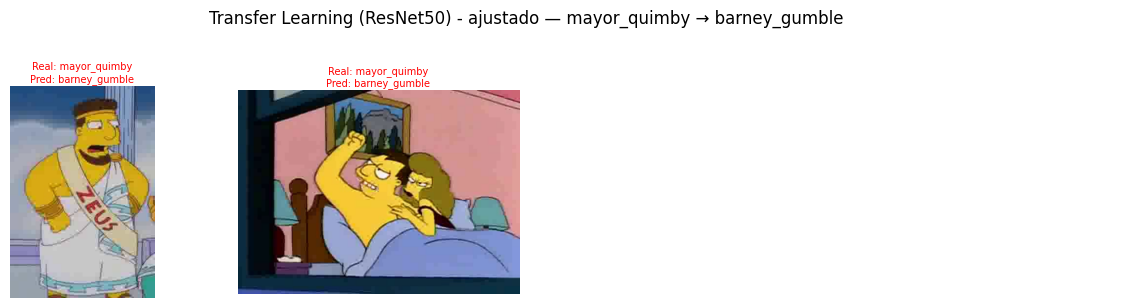


Real: comic_book_guy  →  Predicho: moe_szyslak  (2 imagen/es)


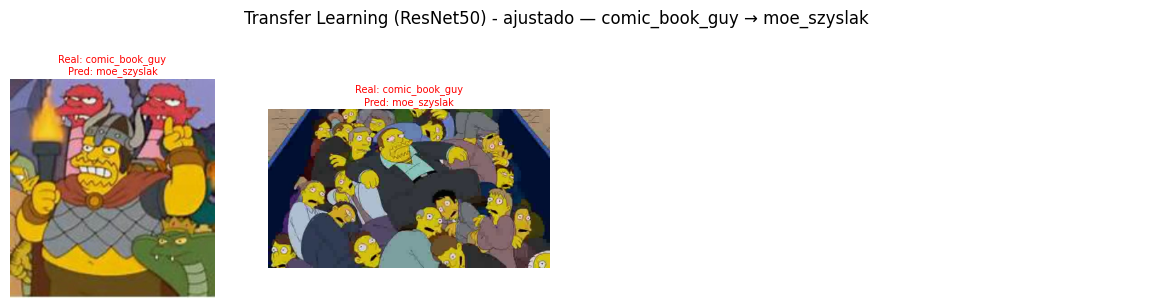


Real: chief_wiggum  →  Predicho: krusty_the_clown  (2 imagen/es)


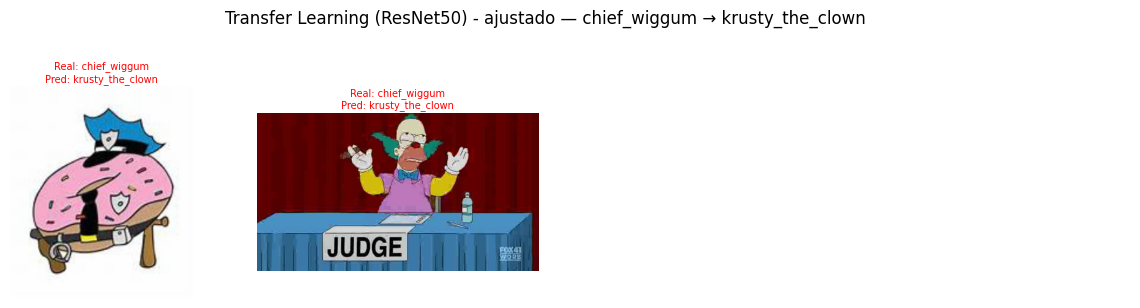


Real: lisa_simpson  →  Predicho: bart_simpson  (2 imagen/es)


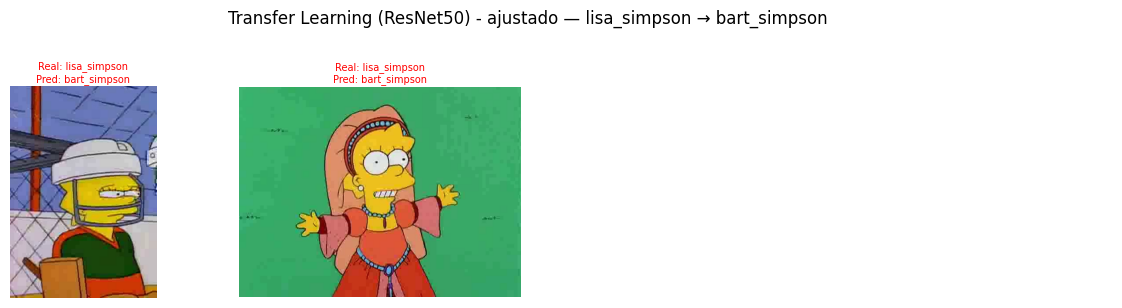


Real: homer_simpson  →  Predicho: lisa_simpson  (2 imagen/es)


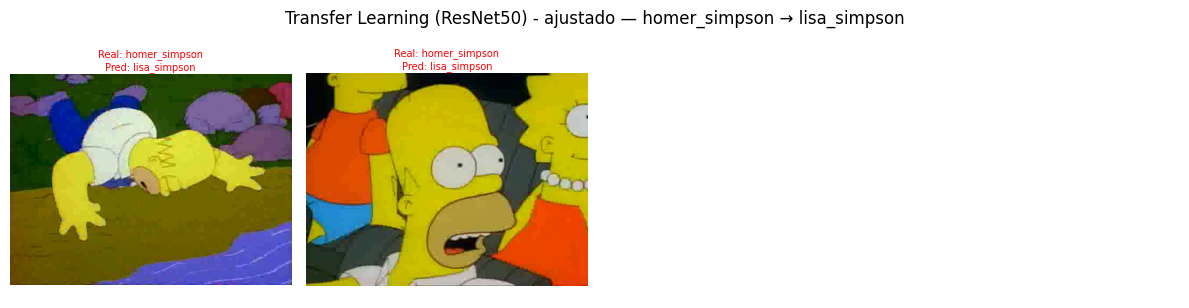

In [101]:
plot_errores_top_pares(dict_predict_m3b, df_test)

Además con el modelo ganador, los errores son incluso más residuales, lo que indica que el ajuste de la arquitectura de ResNet50 ha permitido capturar mejor las características específicas de los personajes de los Simpsons, consiguiendo una generalización excelente incluso en casos más complejos.

# Referencias
- @ALEXATTIA. *"The Simpsons Characters Data. Image dataset of characters from The Simpsons"*. Kaggle
- Amore, Luca. *"Advanced ConvNet for detecting Simpsons characters trained with transfer learning"*. Lucaamore.com.
- @Dantekk. *"Simpson-classifier: Simpson character classifier using CNN"*. Github.
- Li Y. *"Transfer Learning-based CNN Classification for Simpsons Characters"*. CS230 Stanford University.
